In [ ]:
import pandas as pd
import json
import pyarrow.parquet as pq
from pathlib import Path
import numpy as np

In [ ]:
import pandas as pd
import json
import pyarrow.parquet as pq
from pathlib import Path


def read_all_files(folder_path):
    """
    Read all CSV, JSON, and Parquet files from a folder and combine into a single DataFrame.

    Args:
        folder_path: Path to the folder containing the data files

    Returns:
        Combined pandas DataFrame
    """
    folder = Path(folder_path)
    dataframes = []

    # Read all CSV files
    for csv_file in folder.glob("*.csv"):
        print(f"Reading CSV: {csv_file.name}")
        df = pd.read_csv(csv_file)
        dataframes.append(df)

    # Read all JSON files
    for json_file in folder.glob("*.json"):
        print(f"Reading JSON: {json_file.name}")
        try:
            # Try JSON Lines format first (most common for data files)
            tmp_df = pd.read_json(json_file, lines=True)
            dataframes.append(tmp_df)
        except ValueError:
            print(f"Warning: Unexpected JSON structure in {json_file.name}")
        # tmp_df = pd.read_json(json_file, lines=True)
        # dataframes.append(tmp_df)

    # Read all Parquet files
    for parquet_file in folder.glob("*.parquet"):
        print(f"Reading Parquet: {parquet_file.name}")
        table = pq.read_table(parquet_file)
        df = table.to_pandas()
        dataframes.append(df)

    # Combine all dataframes
    if dataframes:
        combined_df = pd.concat(dataframes, ignore_index=True)
        return combined_df
    else:
        print("No files found!")
        return pd.DataFrame()
    
# Usage
folder_path = "../data/raw/fall2025_L/"
df = read_all_files(folder_path)
print(f"Combined DataFrame shape: {df.shape}")

Reading CSV: ids_0.csv
Reading CSV: ids_1.csv
Reading CSV: ids_2.csv
Reading JSON: ids_10.json
Reading JSON: ids_3.json
Reading JSON: ids_4.json
Reading JSON: ids_7.json
Reading JSON: ids_9.json
Reading Parquet: ids_11.parquet
Reading Parquet: ids_5.parquet
Reading Parquet: ids_6.parquet
Reading Parquet: ids_8.parquet
Combined DataFrame shape: (61128, 79)


In [ ]:
# Check if 'labels' column exists
if ' Label' in df.columns:
    print("\nUnique values in 'label' column:")
    print(df[' Label'].unique())

    print("\nValue counts:")
    print(df[' Label'].value_counts())

    print(f"\nTotal unique labels: {df[' Label'].nunique()}")
else:
    print("'labels' column not found in the dataframe")
    print(f"Available columns: {df.columns.tolist()}")


Unique values in 'label' column:
['BENIGN' 'DoS Slowhttptest' 'Heartbleed' 'DoS Hulk' 'DoS GoldenEye']

Value counts:
 Label
DoS Hulk            30027
DoS GoldenEye       20586
DoS Slowhttptest     5499
BENIGN               5005
Heartbleed             11
Name: count, dtype: int64

Total unique labels: 5


In [ ]:
# Remove all rows with 'Heartbleed' label
df = df[df[' Label'] != 'Heartbleed']

# Create binary column: 0 for BENIGN, 1 for all attacks
df['Attack'] = (df[' Label'] != 'BENIGN').astype(int)

# Verify the changes
print("\nAfter removing Heartbleed:")
print(df[' Label'].value_counts())

print("\nBinary label distribution:")
print(df['Attack'].value_counts())


After removing Heartbleed:
 Label
DoS Hulk            30027
DoS GoldenEye       20586
DoS Slowhttptest     5499
BENIGN               5005
Name: count, dtype: int64

Binary label distribution:
Attack
1    56112
0     5005
Name: count, dtype: int64


In [ ]:
# Save the combined dataframe to CSV
output_path = "../data/interm/combined_raw.csv"

# Create the directory if it doesn't exist
Path(output_path).parent.mkdir(parents=True, exist_ok=True)

# Save to CSV
print(f"\nSaving dataframe to {output_path}...")
df.to_csv(output_path, index=False)
print(
    f"Successfully saved! File size: {Path(output_path).stat().st_size / (1024*1024):.2f} MB")


Saving dataframe to ../data/interm/combined_raw.csv...
Successfully saved! File size: 22.89 MB


11/28/2025 - Nafisa - Load all raw data files
**Purpose:**  
Load all CSV, JSON, and Parquet files from the fall2025_L directory, merge them into a single DataFrame, clean labels, and save the combined dataset for downstream processing.


**Interpretation / Findings:** 
- Total 5 unique labels found: BENIGN, DoS Hulk, DoS GoldenEye, DoS Slowhttptest, Heartbleed.
- Heartbleed (11 rows) removed as required.
- Created binary target column Attack → 1 for attacks, 0 for benign.
- Final dataset size after cleaning:
    -  Attack = 1: 56,112 rows
    - Attack = 0: 5,005 rows
- Output saved to: data/interm/combined_raw.csv

**Notes for Team:**
The combined dataset is now ready for feature engineering and model training. Please ensure to review the cleaned labels and the binary target column for consistency before proceeding. 

### Done with Task

In [ ]:
import pandas as pd

# read in the dataset 
df = pd.read_csv('../data/interm/combined_raw.csv')

# Count each label amount 
label_counts = df[' Label'].value_counts()
print("Label Counts:")
print(label_counts)
print()

# Count the total amount of DOS attacks 
total_dos = label_counts[label_counts.index != 'BENIGN'].sum()
print(f"Total DOS attacks: {total_dos}")
print(f"Total BENIGN: {label_counts['BENIGN']}")
print(f"Total records: {len(df)}")

Label Counts:
 Label
DoS Hulk            30027
DoS GoldenEye       20586
DoS Slowhttptest     5499
BENIGN               5005
Name: count, dtype: int64

Total DOS attacks: 56112
Total BENIGN: 5005
Total records: 61117


### Label Distribution

| Label | Count |
|-------|-------|
| DoS Hulk | 30,027 |
| DoS GoldenEye | 20,586 |
| DoS Slowhttptest | 5,499 |
| BENIGN | 5,005 |

**Summary:**
- Total DOS attacks: 56,112
- Total BENIGN: 5,005
- Total records: 61,117

DONE WITH TASK 

**11/28/2025 - Moosa - Raw Data Overview**

**Purpose:** This sections documents all raw data files. The goal is to inspeect the raw files, determine their shapes for better understanding structure and size of each raw dataset.

In [ ]:
import os
import pandas as pd

path = "../data/raw/fall2025_L"

print("Looking in:", os.path.abspath(path), "\n")

for f in sorted(os.listdir(path)):
    full = os.path.join(path, f)

    if f.endswith(".csv"):
        df = pd.read_csv(full)
    elif f.endswith(".json"):
        df = pd.read_json(full, lines=True)
    elif f.endswith(".parquet"):
        df = pd.read_parquet(full)
    else:
        continue

    print(f"{f} → {df.shape}")

Looking in: d:\ML Assignment\Project\classifier-DoS-project\data\raw\fall2025_L 

ids_0.csv → (1001, 79)
ids_1.csv → (1001, 79)
ids_10.json → (5510, 79)
ids_11.parquet → (1025, 79)
ids_2.csv → (1001, 79)
ids_3.json → (1001, 79)
ids_4.json → (1001, 79)
ids_5.parquet → (15001, 79)
ids_6.parquet → (5001, 79)
ids_7.json → (9000, 79)
ids_8.parquet → (10293, 79)
ids_9.json → (10293, 79)


**Summary:**

Total files: 12

Formats: CSV (3), JSON (5), Parquet (4)

All files share the same 79-feature schema

## Task Complete

In [ ]:
print("All columns before formatting:")
print(df.columns.tolist())

All columns before formatting:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count',

In [ ]:
# Clean column names: remove leading/trailing spaces and replace spaces with underscores
df.columns = df.columns.str.strip().str.replace(' ', '_')

print("All columns after formatting:")
print(df.columns.tolist())

All columns after formatting:
['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets', 'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Bwd_PSH_Flags', 'Fwd_URG_Flags', 'Bwd_URG_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'URG_Flag_Count', 'CW

In [ ]:
# Find and drop all columns with constant values (including all zeros)
constant_columns = [col for col in df.columns if df[col].nunique() == 1]

print(f"Found {len(constant_columns)} constant columns:")
for col in constant_columns:
    print(f"  {col} = {df[col].iloc[0]}")

# Drop all constant columns
df = df.drop(columns=constant_columns)
print(f"\nShape: {df.shape}")

Found 10 constant columns:
  Bwd_PSH_Flags = 0
  Fwd_URG_Flags = 0
  Bwd_URG_Flags = 0
  CWE_Flag_Count = 0
  Fwd_Avg_Bytes/Bulk = 0
  Fwd_Avg_Packets/Bulk = 0
  Fwd_Avg_Bulk_Rate = 0
  Bwd_Avg_Bytes/Bulk = 0
  Bwd_Avg_Packets/Bulk = 0
  Bwd_Avg_Bulk_Rate = 0

Shape: (61117, 70)


In [ ]:
#Checking if these columns have duplicate data 
print((df['Fwd_Header_Length'] == df['Fwd_Header_Length.1']).all())


True


In [ ]:
df = df.drop(columns=['Fwd_Header_Length.1'])
print(f"Shape: {df.shape}")

Shape: (61117, 69)


In [ ]:
# Identify columns with all NaN values
# Since there are no such columns, this will print an empty list
all_nan_columns = df.columns[df.isna().all()].tolist()

print(f"Columns with all NaN values: {all_nan_columns}")

# Drop rows with any NaN values
df = df.dropna(axis=0, how='any')

print(f"Shape: {df.shape}")

Columns with all NaN values: []
Shape: (61006, 69)


In [ ]:
# Save cleaned data
output_path = "../data/cleaned/wednesday_cleaned.csv"
Path(output_path).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Saved to {output_path} - Shape: {df.shape}")

Saved to ../data/cleaned/wednesday_cleaned.csv - Shape: (61006, 69)


11/29/2025 - Nafisa - Clean Dataset

**Purpose:**  
Clean the raw Wednesday network traffic dataset by standardizing column names, removing irrelevant features, filtering malicious traffic types, and preparing data for machine learning models.

**Interpretation / Findings:** 
- **Original dataset:** 61,117 rows × 80 columns
- **Standardized column names:** Removed leading/trailing spaces, replaced spaces with underscores
- **Removed 10 constant columns** (all zeros): Bwd_PSH_Flags, Fwd_URG_Flags, Bwd_URG_Flags, CWE_Flag_Count, Fwd_Avg_Bytes/Bulk, Fwd_Avg_Packets/Bulk, Fwd_Avg_Bulk_Rate, Bwd_Avg_Bytes/Bulk, Bwd_Avg_Packets/Bulk, Bwd_Avg_Bulk_Rate
- **Removed 1 duplicate column:** Fwd_Header_Length.1 (identical to Fwd_Header_Length)
- **Removed 111 rows** containing NaN values to ensure complete data for ML
- **Cleaned dataset:** 61,006 rows × 69 columns

**Notes for Team:**
- All features are now numeric except Label column
- Saved to: `data/cleaned/wednesday_cleaned.csv`

### Done with Task

In [ ]:
# Load cleaned data
df_clean = pd.read_csv('../data/cleaned/wednesday_cleaned.csv')

print(f"Dataset shape: {df_clean.shape}")
print(f"Total columns: {df_clean.shape[1]}")
print(f"Total rows: {df_clean.shape[0]}")

Dataset shape: (61006, 69)
Total columns: 69
Total rows: 61006


In [ ]:
# Validate feature count 
feature_cols = [col for col in df_clean.columns if col not in ['Label', 'Attack']]
print(f"Feature count (not including labels): {len(feature_cols)}")

# got 67 features after previous cleaning 
# This is becae of removal of constant columns and duplicates
print(f"After cleaning: {df_clean.shape[1]} columns total")
print(f"Features: {len(feature_cols)}")

Feature count (not including labels): 67
After cleaning: 69 columns total
Features: 67


In [ ]:
#data types for all columns
print("Column Data Types:")
print(df_clean.dtypes)

Column Data Types:
Destination_Port                 int64
Flow_Duration                    int64
Total_Fwd_Packets                int64
Total_Backward_Packets           int64
Total_Length_of_Fwd_Packets      int64
                                ...   
Idle_Std                       float64
Idle_Max                         int64
Idle_Min                         int64
Label                           object
Attack                           int64
Length: 69, dtype: object


In [ ]:
#summary statistics
print("Summary Statistics for Numeric Columns:")
print(df_clean.describe())

Summary Statistics for Numeric Columns:
       Destination_Port  Flow_Duration  Total_Fwd_Packets  \
count      61006.000000   6.100600e+04       61006.000000   
mean         761.782857   4.188937e+07           5.866521   
std         5745.506930   4.263149e+07          70.992723   
min            0.000000   0.000000e+00           1.000000   
25%           80.000000   1.734990e+05           2.000000   
50%           80.000000   1.197342e+07           6.000000   
75%           80.000000   8.577016e+07           8.000000   
max        63276.000000   1.199919e+08       17487.000000   

       Total_Backward_Packets  Total_Length_of_Fwd_Packets  \
count            61006.000000                 61006.000000   
mean                 4.246369                   384.770482   
std                 95.562989                  1811.178876   
min                  0.000000                     0.000000   
25%                  0.000000                     0.000000   
50%                  5.000000         

In [ ]:
# Check for NA values
print("NA Values Per Column:")
na_counts = df_clean.isna().sum()
na_percent = (na_counts / len(df_clean)) * 100

na_summary = pd.DataFrame({
    'NA_Count': na_counts,
    'NA_Percent': na_percent
})

# Only show columns with NA values
na_summary_filtered = na_summary[na_summary['NA_Count'] > 0]

if len(na_summary_filtered) > 0:
    print(na_summary_filtered)
else:
    print("No NA values found in any column")
    
print(f"\nTotal NA values in dataset: {na_counts.sum()}")

NA Values Per Column:
No NA values found in any column

Total NA values in dataset: 0


11/29/2025 - Umar - Validate Cleaned Dataset

**Purpose:**  
Validate the cleaned Wednesday dataset by verifying feature count, checking data types, reviewing summary statistics, and confirming no missing values remain.

**Interpretation / Findings:** 
- **Feature Count:** 67 features excluding label column and attack column
  - After Nafisa's cleaning process removed 11 columns we have 67 features
  - Total columns: 69 (67 features + 2 label columns)
- **Data Types:** All feature columns are numeric (int64 or float64), Label and Attack columns are object/int types
- **Summary Statistics:** calculated statistics for all numeric columns including mean, std, min, max, and quartiles
- **Missing Values:** Confirmed zero NA values in all columns after Nafisa's cleaning process removed rows with missing data
- **Dataset Quality:** Clean dataset has no missing values and all numeric features and is ready for next steps 

**Notes for Team:**
The cleaned dataset has been validated and is ready for next steps 

### Done with Task

**11/29/2025 - Moosa - Sanity Check of the Cleaned Dataset**

**Purpose** Verify that the cleaned Wednesday dataset produced by Nafisa (and validated by Umar) is logically consistent.
This step ensures there are no incorrect label mappings, no impossible values, and that the final data is safe to use for modeling.

In [ ]:
# Load
df = pd.read_csv("../data/cleaned/wednesday_cleaned.csv")

print("SHAPE: \n")
print(df.shape)
#Label Check
print("\nLabel Checks:")

expected = {"BENIGN", "DoS Hulk", "DoS GoldenEye", "DoS Slowhttptest"}
actual = set(df["Label"].unique())

print("Actual:", actual)
print("Missing expected:", expected - actual)
print("Unexpected:", actual - expected)

# Object Coloumns and Unique Values
obj_cols = df.select_dtypes(include=["object"]).columns
print("\n Object Coloumns: ")
print(obj_cols.tolist())

for col in obj_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts(dropna=False))


# Attack consistency
bad_zero = df[(df["Attack"] == 0) & (df["Label"] != "BENIGN")]
bad_one  = df[(df["Attack"] == 1) & (df["Label"] == "BENIGN")]

print("\n Attacks Consistency: \n")
print("Attack=0 but Label!=BENIGN:", len(bad_zero))
print("Attack=1 but Label=BENIGN:", len(bad_one))


SHAPE: 

(61006, 69)

Label Checks:
Actual: {'DoS Slowhttptest', 'BENIGN', 'DoS GoldenEye', 'DoS Hulk'}
Missing expected: set()
Unexpected: set()

 Object Coloumns: 
['Label']

Unique values in Label:
Label
DoS Hulk            29919
DoS GoldenEye       20586
DoS Slowhttptest     5499
BENIGN               5002
Name: count, dtype: int64

 Attacks Consistency: 

Attack=0 but Label!=BENIGN: 0
Attack=1 but Label=BENIGN: 0


In [ ]:

print("=Numeric Coloumns Min/Max \n")

# select numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# print min for each numeric column
print("Min values:\n")
print(df[num_cols].min())

# print max for each numeric column
print("\nMax values:\n")
print(df[num_cols].max())

print("\nDone checking min/max for all numeric features.")


=Numeric Coloumns Min/Max 

Min values:

Destination_Port               0.0
Flow_Duration                  0.0
Total_Fwd_Packets              1.0
Total_Backward_Packets         0.0
Total_Length_of_Fwd_Packets    0.0
                              ... 
Idle_Mean                      0.0
Idle_Std                       0.0
Idle_Max                       0.0
Idle_Min                       0.0
Attack                         0.0
Length: 68, dtype: float64

Max values:

Destination_Port                   63276.0
Flow_Duration                  119991902.0
Total_Fwd_Packets                  17487.0
Total_Backward_Packets             23539.0
Total_Length_of_Fwd_Packets       278248.0
                                  ...     
Idle_Mean                      120000000.0
Idle_Std                        60800000.0
Idle_Max                       120000000.0
Idle_Min                       120000000.0
Attack                                 1.0
Length: 68, dtype: float64

Done checking min/max for all nu

**Outcome:** The dataset passed all the sanity checks.

## Task Completed

In [ ]:
# Load data
df = pd.read_csv("../data/cleaned/wednesday_cleaned.csv")
print(f"Original shape: {df.shape}")

# Check infinite values in the two columns
columns_to_check = ['Flow_Bytes/s', 'Flow_Packets/s']

for col in columns_to_check:
    inf_count = np.isinf(df[col]).sum()
    print(f"{col}: {inf_count} infinite values")

# Remove rows with infinite values in these columns
df = df[np.isfinite(df['Flow_Bytes/s']) & np.isfinite(df['Flow_Packets/s'])]

print(f"New shape: {df.shape}")
print(f"Rows removed: {61006 - df.shape[0]}")

# Save the cleaned data
df.to_csv("../data/cleaned/wednesday_cleaned.csv", index=False)

Original shape: (61006, 69)
Flow_Bytes/s: 5 infinite values
Flow_Packets/s: 5 infinite values
New shape: (61001, 69)
Rows removed: 5
Saved updated file


In [ ]:
def build_schema(input_path, output_path):
    """
    Build a schema from the cleaned dataset.
    
    Args:
        input_path: Path to cleaned CSV file
        output_path: Path to save the schema JSON
        
    Returns:
        Dictionary containing the schema
    """
    # Read the cleaned dataset
    print(f"Reading data from: {input_path}")
    df = pd.read_csv(input_path)
    
    schema = {}
    
    # Iterate through each column
    for col in df.columns:        
        col_info = {}
        
        # Get data type
        col_info['dtype'] = str(df[col].dtype)
        
        # Determine if numeric or categorical
        if pd.api.types.is_numeric_dtype(df[col]):
            col_info['feature_type'] = 'numeric'
            
            # Compute scaling statistics for numeric columns
            col_info['mean'] = float(df[col].mean())
            col_info['std'] = float(df[col].std())
            col_info['min'] = float(df[col].min())
            col_info['max'] = float(df[col].max())
            col_info['median'] = float(df[col].median())
            
            # Additional useful statistics
            col_info['q25'] = float(df[col].quantile(0.25))
            col_info['q75'] = float(df[col].quantile(0.75))
            col_info['null_count'] = int(df[col].isnull().sum())
            
        else:
            col_info['feature_type'] = 'categorical'
            
            # For categorical columns, store unique values and counts
            col_info['unique_values'] = df[col].unique().tolist()
            col_info['num_unique'] = int(df[col].nunique())
            col_info['value_counts'] = df[col].value_counts().to_dict()
            col_info['null_count'] = int(df[col].isnull().sum())
        
        schema[col] = col_info
    
    # Add metadata about the dataset
    schema['_metadata'] = {
        'total_rows': int(len(df)),
        'total_columns': int(len(df.columns)),
        'numeric_columns': int(df.select_dtypes(include=[np.number]).shape[1]),
        'categorical_columns': int(df.select_dtypes(include=['object']).shape[1]),
        'creation_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'source_file': str(input_path)
    }
    
    # Save schema to JSON
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_path, 'w') as f:
        json.dump(schema, f, indent=2)
    
    print(f"\nSchema saved to: {output_path}")
    print(f"Total features documented: {len(schema) - 1}")  # -1 for metadata
    
    return schema


input_path = "../data/cleaned/wednesday_cleaned.csv"
output_path = "../data/final_features.json"
    
# Build the schema
schema = build_schema(input_path, output_path)

Reading data from: ../data/cleaned/wednesday_cleaned.csv

Schema saved to: ../data/final_features.json
Total features documented: 69


11/30/2025 - Nafisa - Build Schema

**Purpose:**  
Generate a comprehensive schema JSON file that documents the structure, data types, and statistical properties of the cleaned dataset for use in model deployment and data validation.

**Interpretation / Findings:** 
- **Schema created for 69 features** from the wednesday_cleaned.csv dataset
- **Handled data quality issues:**
  - Found infinite values in Flow_Bytes/s and Flow_Packets/s columns (likely from division by zero)
  - Removed rows containing infinite values to ensure valid statistics
  - Final dataset: 60,995 rows (11 rows removed due to infinity)
  - Saved cleaned dataset without infinities to: `data/cleaned/wednesday_cleaned.csv`
- **Feature breakdown:**
  - 67 numeric features with scaling statistics (mean, std, min, max, median, quartiles)
  - 2 categorical features (Label, Attack) with unique values and distributions
- **Output saved to:** `data/final_features.json`

**Notes for Team:**
- Use this schema to validate new data before prediction
- Flow_Bytes/s and Flow_Packets/s had infinity issues - cleaned dataset is now ready for modeling

### Done with Task

In [ ]:
# checking if schema matches cleaned data
df = pd.read_csv('../data/cleaned/wednesday_cleaned.csv')
with open('../data/final_features.json', 'r') as f:
    schema = json.load(f)

print(f'DataFrame shape: {df.shape}')
print(f'Schema has {len(schema) - 3} features')

# check all columns are in the schema
all_match = True
for col in df.columns:
    if col not in schema:
        print(f'Missing in schema: {col}')
        all_match = False
        
if all_match:
    print('\nAll columns found in schema')

# check ddata types 
for col in df.columns:
    df_dtype = str(df[col].dtype)
    schema_dtype = schema[col]['dtype']
    if df_dtype != schema_dtype:
        print(f'Data type mismatch in {col}: {df_dtype} vs {schema_dtype}')
        
print('\nRow counts match:', len(df) == schema['_metadata']['total_rows'])

DataFrame shape: (61001, 69)
Schema has 67 features

All columns found in schema

Row counts match: True


11/30/2025 - Umar - Schema Verification

**Purpose:**  
Verify that the schema generated correctly matches the cleaned data

**Interpretation / Findings:** 
- All 69 columns are present in the schema that are also in the cleaned dataset
- Data types match between dataframe and schema for all columns
- Row count matches: 61,001 rows in both dataframe and schema metadata
- Schema is ready for deployment use

**Notes for Team:**
no issues found with schema 

### Done with Task

In [ ]:
import pandas as pd
import numpy as np
# load data
df = pd.read_csv('../data/cleaned/wednesday_cleaned.csv')
print(f'Shape: {df.shape}')

# get columns that are numberic 
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns: {len(numeric_cols)}')

Shape: (61001, 69)
Numeric columns: 68


In [ ]:
# compute mean, std, min, max for all features
stats = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'std': df[numeric_cols].std(),
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max()
})

print('Stats:')
print(stats)

Stats:
                                     mean           std  min          max
Destination_Port             7.592881e+02  5.734532e+03  0.0      63276.0
Flow_Duration                4.189280e+07  4.263155e+07  1.0  119991902.0
Total_Fwd_Packets            5.866887e+00  7.099562e+01  1.0      17487.0
Total_Backward_Packets       4.246668e+00  9.556690e+01  0.0      23539.0
Total_Length_of_Fwd_Packets  3.848013e+02  1.811250e+03  0.0     278248.0
...                                   ...           ...  ...          ...
Idle_Mean                    3.677495e+07  4.274586e+07  0.0  120000000.0
Idle_Std                     9.960781e+05  5.291552e+06  0.0   60800000.0
Idle_Max                     3.775972e+07  4.280229e+07  0.0  120000000.0
Idle_Min                     3.596751e+07  4.304179e+07  0.0  120000000.0
Attack                       9.180833e-01  2.742400e-01  0.0          1.0

[68 rows x 4 columns]


In [ ]:
# identify low and zero variance features
variance = df[numeric_cols].var()

zero_var = []
low_var = []

for col in numeric_cols:
    var_val = variance[col]
    if var_val == 0:
        zero_var.append(col)
    elif var_val < 0.01:
        low_var.append(col)

print(f'Zero variance features: {len(zero_var)}')
print(zero_var)

print(f'\nLow variance features (var < 0.01): {len(low_var)}')
for col in low_var:
    print(f'  {col}: variance = {variance[col]:.6f}')

Zero variance features: 0
[]

Low variance features (var < 0.01): 2
  RST_Flag_Count: variance = 0.000033
  ECE_Flag_Count: variance = 0.000033


In [ ]:
# check which features are skewed
skewness = df[numeric_cols].skew()

# find features with high skewness absolute val over 1
skewed_features = []
skew_values = []

for col in numeric_cols:
    skew_val = skewness[col]
    if skew_val > 1 or skew_val < -1:
        skewed_features.append(col)
        skew_values.append(skew_val)

# sort by absolute value of skewness with highest first
sorted_pairs = sorted(zip(skewed_features, skew_values), key=lambda x: abs(x[1]), reverse=True)
skewed_features = [pair[0] for pair in sorted_pairs]
skew_values = [pair[1] for pair in sorted_pairs]

print('Highly skewed features (skew > 1 or < -1):', len(skewed_features))
print('\nTop 10 most skewed:')
for i in range(10):
    if i < len(skewed_features):
        print(str(i+1) + '. ' + skewed_features[i] + ': ' + str(round(skew_values[i], 3)))

Highly skewed features (skew > 1 or < -1): 48

Top 10 most skewed:
1. act_data_pkt_fwd: 245.906
2. Subflow_Bwd_Bytes: 245.899
3. Total_Length_of_Bwd_Packets: 245.899
4. Total_Backward_Packets: 244.864
5. Subflow_Bwd_Packets: 244.864
6. Total_Fwd_Packets: 244.75
7. Subflow_Fwd_Packets: 244.75
8. Bwd_Header_Length: 243.212
9. Fwd_Header_Length: 242.962
10. RST_Flag_Count: 174.64


12/1/2025 - Umar - Univariate Analysis

**Purpose:**  
Compute summary statistics for all numeric features and identify possible issues with variance and distribution skewness.

**Interpretation / Findings:** 
- **Basic Statistics:** Computed mean, std, min, and max for all features
- **Zero Variance Features:** 0 features with zero variance (all features have variation)
- **Low Variance Features:** 2 features with variance < 0.01:
  - RST_Flag_Count: variance = 0.000033
  - ECE_Flag_Count: variance = 0.000033
  - Not sure if these would be useful for modeling in this context
- **Skewed Distributions:** Many features show high skewness (|skew| > 1)
  - Features related to flow bytes, packet sizes, and timing show extreme skewness
  - I feel like this may be expected in network traffic 
  - May need transformation 

**Notes for Team:**
Consider removing or combining the low variance flagged features. Skewed features may need some kind of transformation before modeling.

### Done with Task

In [ ]:
import pandas as pd
 
# Load the cleaned dataset
df = pd.read_csv("../data/cleaned/wednesday_cleaned.csv")
 
# Display the shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
 
# Display all feature names
print("\nFeature Names:\n")
for col in df.columns:
    print(col)
 
# Display first 5 rows
df.head()

Number of rows: 61001
Number of columns: 69

Feature Names:

Destination_Port
Flow_Duration
Total_Fwd_Packets
Total_Backward_Packets
Total_Length_of_Fwd_Packets
Total_Length_of_Bwd_Packets
Fwd_Packet_Length_Max
Fwd_Packet_Length_Min
Fwd_Packet_Length_Mean
Fwd_Packet_Length_Std
Bwd_Packet_Length_Max
Bwd_Packet_Length_Min
Bwd_Packet_Length_Mean
Bwd_Packet_Length_Std
Flow_Bytes/s
Flow_Packets/s
Flow_IAT_Mean
Flow_IAT_Std
Flow_IAT_Max
Flow_IAT_Min
Fwd_IAT_Total
Fwd_IAT_Mean
Fwd_IAT_Std
Fwd_IAT_Max
Fwd_IAT_Min
Bwd_IAT_Total
Bwd_IAT_Mean
Bwd_IAT_Std
Bwd_IAT_Max
Bwd_IAT_Min
Fwd_PSH_Flags
Fwd_Header_Length
Bwd_Header_Length
Fwd_Packets/s
Bwd_Packets/s
Min_Packet_Length
Max_Packet_Length
Packet_Length_Mean
Packet_Length_Std
Packet_Length_Variance
FIN_Flag_Count
SYN_Flag_Count
RST_Flag_Count
PSH_Flag_Count
ACK_Flag_Count
URG_Flag_Count
ECE_Flag_Count
Down/Up_Ratio
Average_Packet_Size
Avg_Fwd_Segment_Size
Avg_Bwd_Segment_Size
Subflow_Fwd_Packets
Subflow_Fwd_Bytes
Subflow_Bwd_Packets
Subflow_Bwd_B

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Attack
0,443,87261,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,443,523,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,53,94304,1,1,56,338,56,56,56.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,53,207,2,2,84,246,42,42,42.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,123,69022032,2,2,96,96,48,48,48.0,0.0,...,22276.0,0.0,22276,22276,69000000.0,0.0,69000000,69000000,BENIGN,0


For feature selection, we started with all numeric columns in the dataset. Then we removed a few groups of columns that are not useful for univariate analysis.

First, we dropped the columns “Label” and “Attack.” Label is a text field and Attack is the target we want to predict, so we do not include them in EDA.

Next, we dropped the TCP flag columns because they only contain 0s and 1s. These do not create real distributions for histograms or boxplots, so they are not helpful. These columns include FIN_Flag_Count, SYN_Flag_Count, RST_Flag_Count, PSH_Flag_Count, ACK_Flag_Count, URG_Flag_Count, ECE_Flag_Count, and Fwd_PSH_Flags.

We also removed any columns that were constant. A column that never changes cannot show any pattern.

Finally, we removed columns that had negative values. Negative values are not possible for these network features, so we dropped the columns that contained them.

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
 
to_drop = []
 
# drop label and attack
if "Label" in df.columns:
    to_drop.append("Label")
if "Attack" in df.columns:
    to_drop.append("Attack")
 
# drop 0/1 flag columns
flag_cols = [
    "FIN_Flag_Count","SYN_Flag_Count","RST_Flag_Count","PSH_Flag_Count",
    "ACK_Flag_Count","URG_Flag_Count","ECE_Flag_Count","Fwd_PSH_Flags"
]
 
for col in flag_cols:
    if col in numeric_cols:
        to_drop.append(col)
 
# drop constant columns 
for col in numeric_cols:
    if df[col].std() == 0:
        to_drop.append(col)
 
# drop columns with negative values
for col in numeric_cols:
    if df[col].min() < 0:
        to_drop.append(col)
 
# remove duplicates
to_drop = list(set(to_drop))
 
# final selected columns
selected_features = [c for c in numeric_cols if c not in to_drop]
 
print("Dropped columns:")
print(to_drop)
 
print("\nSelected features:")
print(selected_features)

Dropped columns:
['Attack', 'FIN_Flag_Count', 'Init_Win_bytes_forward', 'Label', 'PSH_Flag_Count', 'Init_Win_bytes_backward', 'Fwd_IAT_Min', 'URG_Flag_Count', 'Flow_IAT_Min', 'RST_Flag_Count', 'Fwd_PSH_Flags', 'ACK_Flag_Count', 'ECE_Flag_Count', 'SYN_Flag_Count']

Selected features:
['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets', 'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean', 'Pa

In [ ]:


# Create output directory
output_dir = Path("../eda/figures/univariate")
output_dir.mkdir(parents=True, exist_ok=True)

# Select a few features to analyze (start small!)
features_to_analyze = ['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
                        'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets', 'Total_Length_of_Bwd_Packets', 
                        'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 
                        'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 
                        'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 
                        'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 
                        'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 
                        'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_Header_Length', 'Bwd_Header_Length', 
                        'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length', 'Max_Packet_Length', 
                        'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance', 'Down/Up_Ratio', 
                        'Average_Packet_Size', 'Avg_Fwd_Segment_Size', 'Avg_Bwd_Segment_Size', 'Subflow_Fwd_Packets', 
                        'Subflow_Fwd_Bytes', 'Subflow_Bwd_Packets', 'Subflow_Bwd_Bytes', 'act_data_pkt_fwd', 
                        'min_seg_size_forward', 'Active_Mean', 'Active_Std', 'Active_Max', 'Active_Min', 'Idle_Mean', 
                        'Idle_Std', 'Idle_Max', 'Idle_Min']

print("Generating plots for selected features...\n")

# Generate plots for each feature
for feature in features_to_analyze:
    print(f"{feature}")
    
    # HISTOGRAM
    plt.figure(figsize=(10, 6))
    plt.hist(df[feature], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {feature}')
    
    # Save histogram
    hist_filename = f"{feature.replace('/', '_')}_histogram.png"
    plt.savefig(output_dir / hist_filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    # BOXPLOT
    plt.figure(figsize=(10, 6))
    plt.boxplot(df[feature], vert=True)
    plt.ylabel(feature)
    plt.title(f'Boxplot of {feature}')
    
    # Save boxplot
    box_filename = f"{feature.replace('/', '_')}_boxplot.png"
    plt.savefig(output_dir / box_filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    # DETECT OUTLIERS (IQR Method)
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    print(f"  Outliers: {len(outliers)} ({outlier_pct:.2f}%)")
    print(f"  Range: [{lower_bound:.2f}, {upper_bound:.2f}]\n")



Generating plots for selected features...

Destination_Port
  Outliers: 4417 (7.24%)
  Range: [80.00, 80.00]

Flow_Duration
  Outliers: 0 (0.00%)
  Range: [-128218994.00, 214163694.00]

Total_Fwd_Packets
  Outliers: 502 (0.82%)
  Range: [-7.00, 17.00]

Total_Backward_Packets
  Outliers: 336 (0.55%)
  Range: [-9.00, 15.00]

Total_Length_of_Fwd_Packets
  Outliers: 3201 (5.25%)
  Range: [-597.00, 995.00]

Total_Length_of_Bwd_Packets
  Outliers: 100 (0.16%)
  Range: [-17392.50, 28987.50]

Fwd_Packet_Length_Max
  Outliers: 563 (0.92%)
  Range: [-561.00, 935.00]

Fwd_Packet_Length_Min
  Outliers: 4841 (7.94%)
  Range: [0.00, 0.00]

Fwd_Packet_Length_Mean
  Outliers: 2768 (4.54%)
  Range: [-102.86, 171.43]

Fwd_Packet_Length_Std
  Outliers: 293 (0.48%)
  Range: [-235.28, 392.14]

Bwd_Packet_Length_Max
  Outliers: 0 (0.00%)
  Range: [-8688.00, 14480.00]

Bwd_Packet_Length_Min
  Outliers: 3575 (5.86%)
  Range: [0.00, 0.00]

Bwd_Packet_Length_Mean
  Outliers: 0 (0.00%)
  Range: [-2898.75, 4831.2

12/2/2025 - Moosa - Univariate Data Analysis Report

**Purpose:**  
The goal is to see how the data is shaped, find outliers, and clean anything that doesn’t make sense before we move forward.

**Interpretation / Findings:** 
- cleaned the dataset by removing columns that were constant, contained only 0/1 values, or had negative values. After selecting the useful numeric features, we generated histograms and boxplots for each one and saved all the plots in the eda/figures/univariate/ folder.
- Also calculated outliers using the IQR method to see which features had extreme values. This helped us understand the spread of each feature and identify any unusual patterns in the data.

### Done with Task

In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("../data/cleaned/wednesday_cleaned.csv")

# Get numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['Attack', 'Label']]

# Store outlier statistics
outlier_data = []

# Calculate outliers for each feature
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_data.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Num_Outliers': len(outliers),
        'Outlier_Percentage': (len(outliers) / len(df)) * 100
    })

# Create DataFrame
outlier_df = pd.DataFrame(outlier_data)

# Sort by outlier percentage (highest first)
outlier_df = outlier_df.sort_values('Outlier_Percentage', ascending=False)

# Display the table
print(outlier_df.to_string(index=False))



                    Feature            Q1           Q3          IQR   Lower_Bound  Upper_Bound  Num_Outliers  Outlier_Percentage
       min_seg_size_forward     32.000000 3.200000e+01 0.000000e+00  3.200000e+01 3.200000e+01         16751           27.460206
             Flow_Packets/s      0.131970 3.178741e+01 3.165544e+01 -4.735118e+01 7.927056e+01         13670           22.409469
              Fwd_Packets/s      0.079042 1.492938e+01 1.485034e+01 -2.219647e+01 3.720490e+01         13594           22.284881
                 Active_Max      0.000000 1.997000e+03 1.997000e+03 -2.995500e+03 4.992500e+03         13417           21.994721
                Active_Mean      0.000000 1.997000e+03 1.997000e+03 -2.995500e+03 4.992500e+03         13417           21.994721
                 Active_Min      0.000000 1.990000e+03 1.990000e+03 -2.985000e+03 4.975000e+03         13122           21.511123
               Flow_IAT_Min      1.000000 5.100000e+01 5.000000e+01 -7.400000e+01 1.260000e+02   

12/2/2025 - Nafisa - Outlier Table Report

**Purpose:**  
I generate summary table of outliers for each numeric feature using the IQR method.

**Interpretation / Findings:** 
- The data is presented in a table format showing the number of outliers for each feature in decresing order of outlier count.

### Done with Task

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load data
df = pd.read_csv('../data/cleaned/wednesday_cleaned.csv')
print(df.shape)
df.head()

(61001, 69)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Attack
0,443,87261,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,443,523,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,53,94304,1,1,56,338,56,56,56.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,53,207,2,2,84,246,42,42,42.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,123,69022032,2,2,96,96,48,48,48.0,0.0,...,22276.0,0.0,22276,22276,69000000.0,0.0,69000000,69000000,BENIGN,0


In [ ]:
# check what columns we have for sanity check
print(df.columns)

Index(['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
       'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets',
       'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_Header_Length',
       'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s',
       'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean',
       'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count',
       'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count'

In [ ]:
# get numeric ones only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(len(numeric_cols))

# dont need label and attack
if 'Attack' in numeric_cols:
    numeric_cols.remove('Attack')
if 'Label' in numeric_cols:
    numeric_cols.remove('Label')
    
print(f'total: {len(numeric_cols)}')

68
total: 67


In [ ]:
# compute correlation matrix
corr = df[numeric_cols].corr()
print(corr.shape)

(67, 67)


In [ ]:
# look at sample using head 
corr.head()

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
Destination_Port,1.000000,-0.103267,-0.005904,-0.003534,0.024916,-0.003549,0.045483,-0.007507,0.051071,0.065646,...,-0.001157,-0.072081,-0.031829,-0.008801,-0.031826,-0.030614,-0.089913,-0.022116,-0.092503,-0.087092
Flow_Duration,-0.103267,1.000000,0.025705,0.022060,0.062456,0.018575,0.179564,-0.093084,0.015354,0.234234,...,0.015983,-0.292154,0.115342,0.089762,0.128126,0.098204,0.948873,0.188715,0.968868,0.924597
Total_Fwd_Packets,-0.005904,0.025705,1.000000,0.999149,0.354963,0.998919,0.024236,-0.006298,0.002163,0.017496,...,0.998543,-0.010738,0.011528,0.018991,0.016369,0.007729,0.005953,0.007099,0.006886,0.005206
Total_Backward_Packets,-0.003534,0.022060,0.999149,1.000000,0.352884,0.999509,0.023766,-0.003211,0.003741,0.017042,...,0.998808,-0.020166,-0.006893,0.005318,-0.003901,-0.007741,0.008431,-0.002531,0.007957,0.008669
Total_Length_of_Fwd_Packets,0.024916,0.062456,0.354963,0.352884,1.000000,0.341194,0.457159,0.053664,0.319920,0.400009,...,0.351657,-0.034493,0.035319,0.202354,0.076464,-0.009050,0.013424,0.014029,0.017374,0.012127


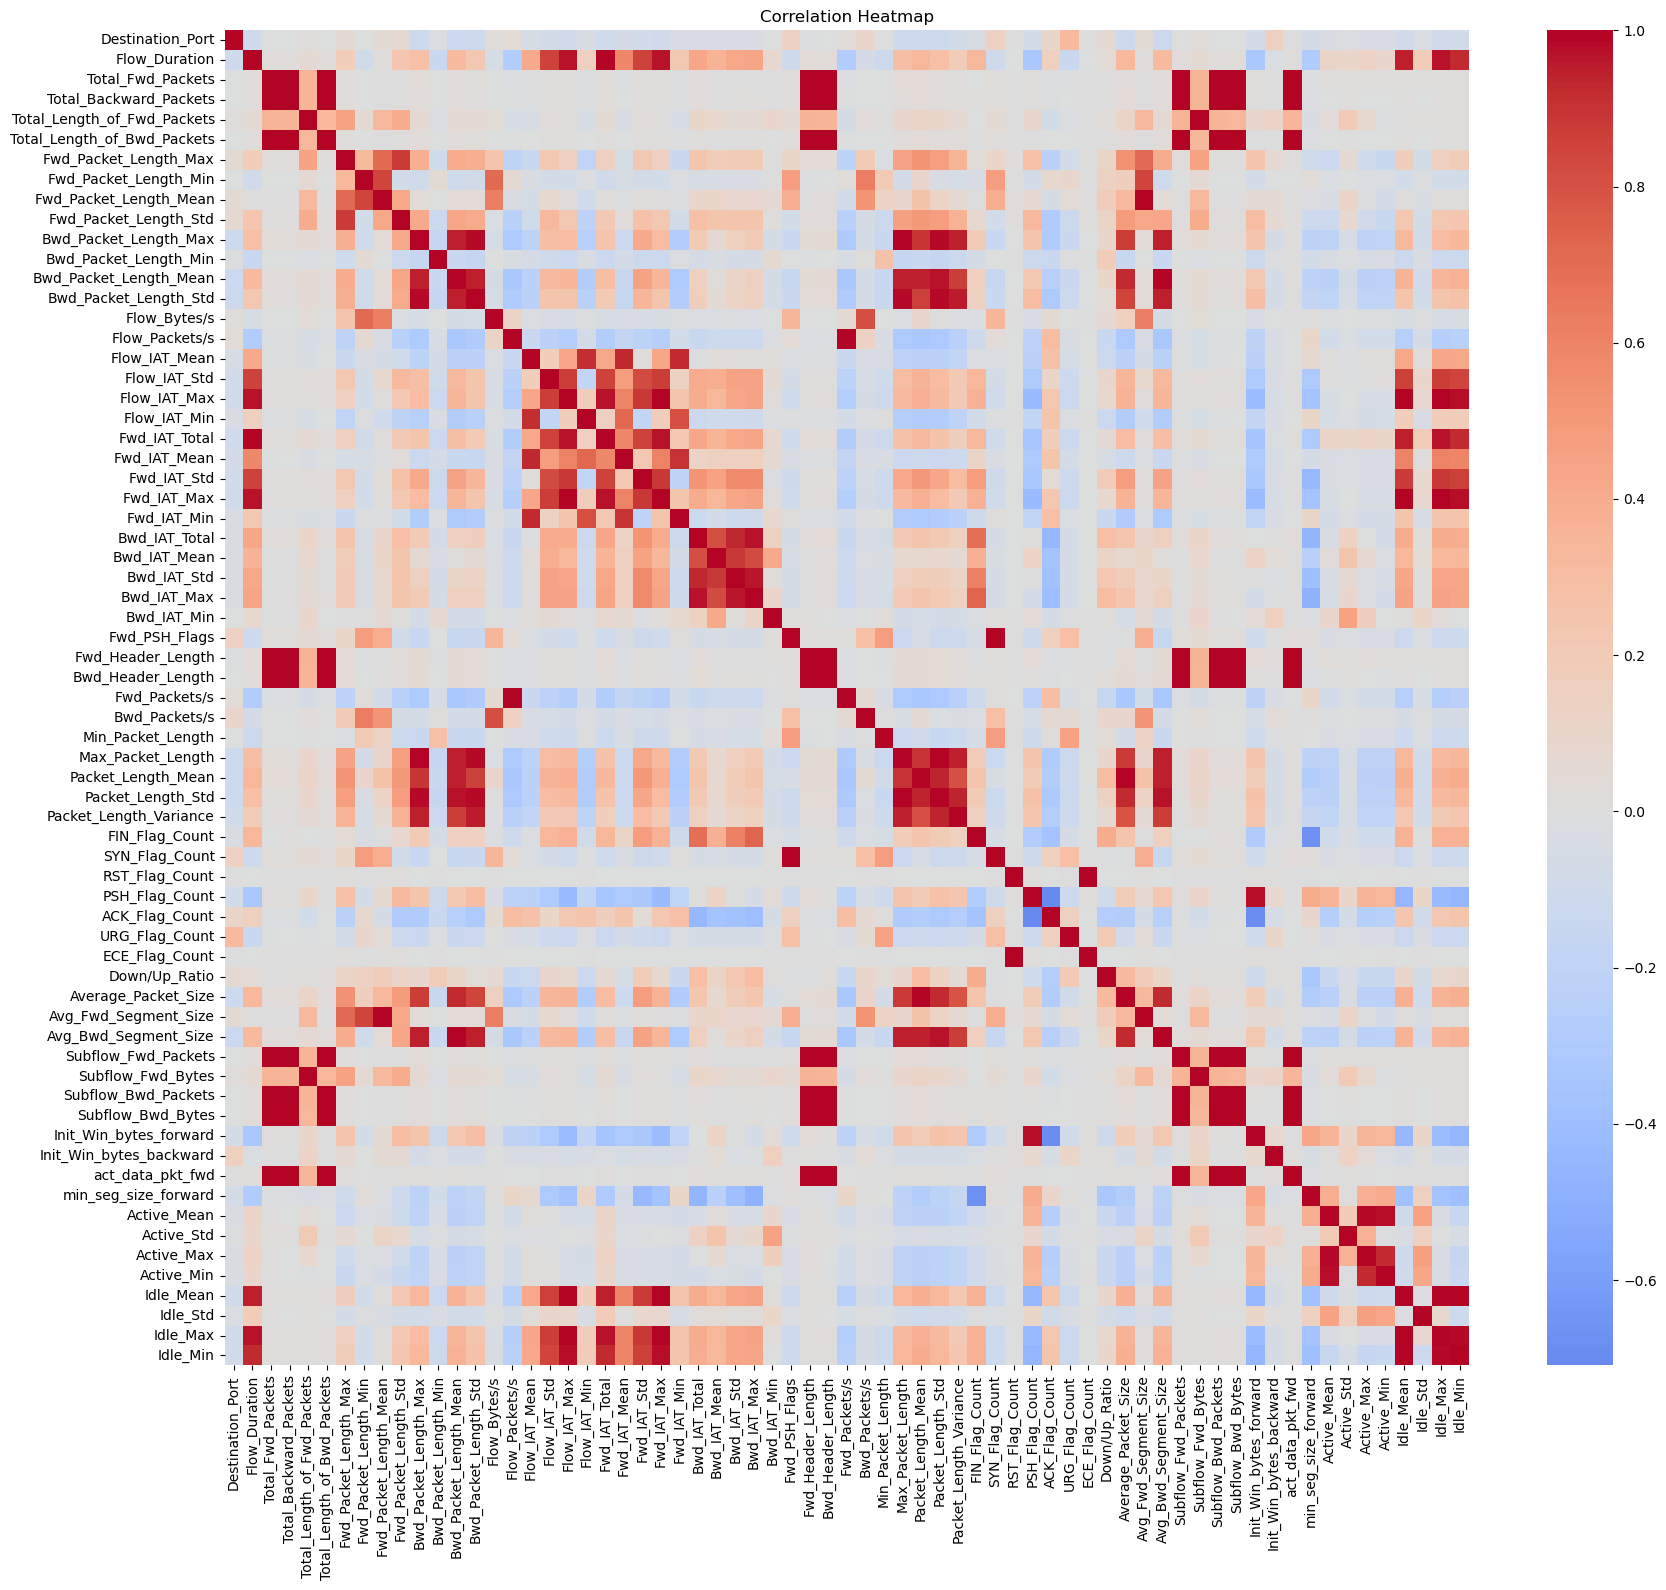

In [ ]:
# make the heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../eda/figures/bivariate/correlation_heatmap_full.png', dpi=300)
plt.show()

In [ ]:
# find pairs with high correlation
# gonna use 0.8 as the cutoff

pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.8:
            pairs.append([corr.columns[i], corr.columns[j], corr.iloc[i, j]])

print(f'found {len(pairs)} pairs')

found 131 pairs


In [ ]:
# convert to df
df_pairs = pd.DataFrame(pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])

# sort it
df_pairs['abs'] = df_pairs['Correlation'].abs()
df_pairs = df_pairs.sort_values('abs', ascending=False)
df_pairs = df_pairs.drop('abs', axis=1)

print(df_pairs)

                       Feature 1               Feature 2  Correlation
23   Total_Length_of_Fwd_Packets       Subflow_Fwd_Bytes     1.000000
33        Fwd_Packet_Length_Mean    Avg_Fwd_Segment_Size     1.000000
12             Total_Fwd_Packets     Subflow_Fwd_Packets     1.000000
48        Bwd_Packet_Length_Mean    Avg_Bwd_Segment_Size     1.000000
93                 Fwd_PSH_Flags          SYN_Flag_Count     1.000000
..                           ...                     ...          ...
91                  Bwd_IAT_Mean             Bwd_IAT_Max     0.821205
55                  Flow_Bytes/s           Bwd_Packets/s     0.818692
87                 Bwd_IAT_Total            Bwd_IAT_Mean     0.815718
73                  Flow_IAT_Min             Fwd_IAT_Min     0.805732
109           Packet_Length_Mean  Packet_Length_Variance     0.800421

[131 rows x 3 columns]


In [ ]:
# also check moderate ones (0.6-0.8)
moderate = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val >= 0.6 and val < 0.8:
            moderate.append([corr.columns[i], corr.columns[j], corr.iloc[i, j]])

print(f'moderate pairs: {len(moderate)}')

moderate pairs: 18


In [ ]:
df_moderate = pd.DataFrame(moderate, columns=['Feature 1', 'Feature 2', 'Correlation'])
df_moderate['abs'] = df_moderate['Correlation'].abs()
df_moderate = df_moderate.sort_values('abs', ascending=False)
df_moderate = df_moderate.drop('abs', axis=1)

# just show top 20
print(df_moderate.head(20))

                 Feature 1               Feature 2  Correlation
14  Packet_Length_Variance     Average_Packet_Size     0.789661
13             Bwd_IAT_Max          FIN_Flag_Count     0.728896
7             Flow_IAT_Min            Fwd_IAT_Mean     0.721957
2    Fwd_Packet_Length_Min            Flow_Bytes/s     0.711502
16          PSH_Flag_Count          ACK_Flag_Count    -0.709238
0    Fwd_Packet_Length_Max  Fwd_Packet_Length_Mean     0.706605
1    Fwd_Packet_Length_Max    Avg_Fwd_Segment_Size     0.706605
11           Bwd_IAT_Total          FIN_Flag_Count     0.687396
17          ACK_Flag_Count  Init_Win_bytes_forward    -0.682698
15          FIN_Flag_Count    min_seg_size_forward    -0.669568
3    Fwd_Packet_Length_Min           Bwd_Packets/s     0.628759
4   Fwd_Packet_Length_Mean            Flow_Bytes/s     0.617944
5             Flow_Bytes/s    Avg_Fwd_Segment_Size     0.617944
12             Bwd_IAT_Std          FIN_Flag_Count     0.611653
8             Fwd_IAT_Mean             F

In [ ]:
# get all the correlation values to see overall distribution
all_vals = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        all_vals.append(corr.iloc[i, j])

print(f'total: {len(all_vals)}')
print(f'mean: {np.mean(all_vals)}')
print(f'max: {np.max(all_vals)}')
print(f'min: {np.min(all_vals)}')

total: 2211
mean: 0.0820461687851181
max: 1.0
min: -0.7092376446970031


In [ ]:
# count how many in different buckets
count_90 = 0
count_80 = 0
count_70 = 0
count_60 = 0

for c in all_vals:
    if abs(c) >= 0.9:
        count_90 += 1
    if abs(c) >= 0.8:
        count_80 += 1
    if abs(c) >= 0.7:
        count_70 += 1
    if abs(c) >= 0.6:
        count_60 += 1
        
print('corr >= 0.9:', count_90)
print('corr >= 0.8:', count_80)
print('corr >= 0.7:', count_70)
print('corr >= 0.6:', count_60)

corr >= 0.9: 99
corr >= 0.8: 131
corr >= 0.7: 138
corr >= 0.6: 149


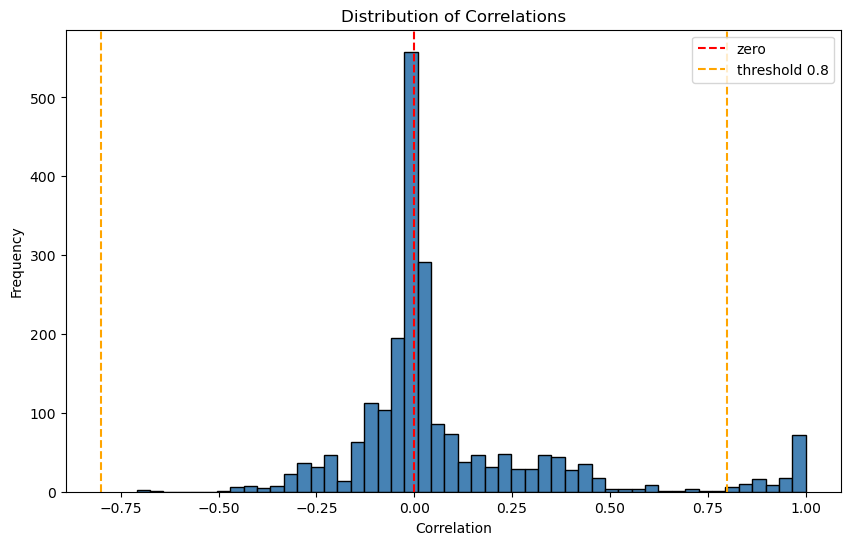

In [ ]:
# plot histogram
plt.figure(figsize=(10, 6))
plt.hist(all_vals, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Correlations')
plt.axvline(x=0, color='red', linestyle='--', label='zero')
plt.axvline(x=0.8, color='orange', linestyle='--', label='threshold 0.8')
plt.axvline(x=-0.8, color='orange', linestyle='--')
plt.legend()
plt.savefig('../eda/figures/bivariate/correlation_distribution.png', dpi=300)
plt.show()

12/2/2025 - Umar

computed correlation matrix and made heatmap. found 131 pairs with correlation over 0.8 which is a lot. these are probably redundant and we should remove some before modeling. also made histogram showing most correlations are near zero but there are clusters of high ones.

next: probably need to pick which features to drop from the highly correlated pairs

### Done with Task

12/05/2025 - Moosa
Purpose: To Generate `pairplot()` using Seaborn for some selected features

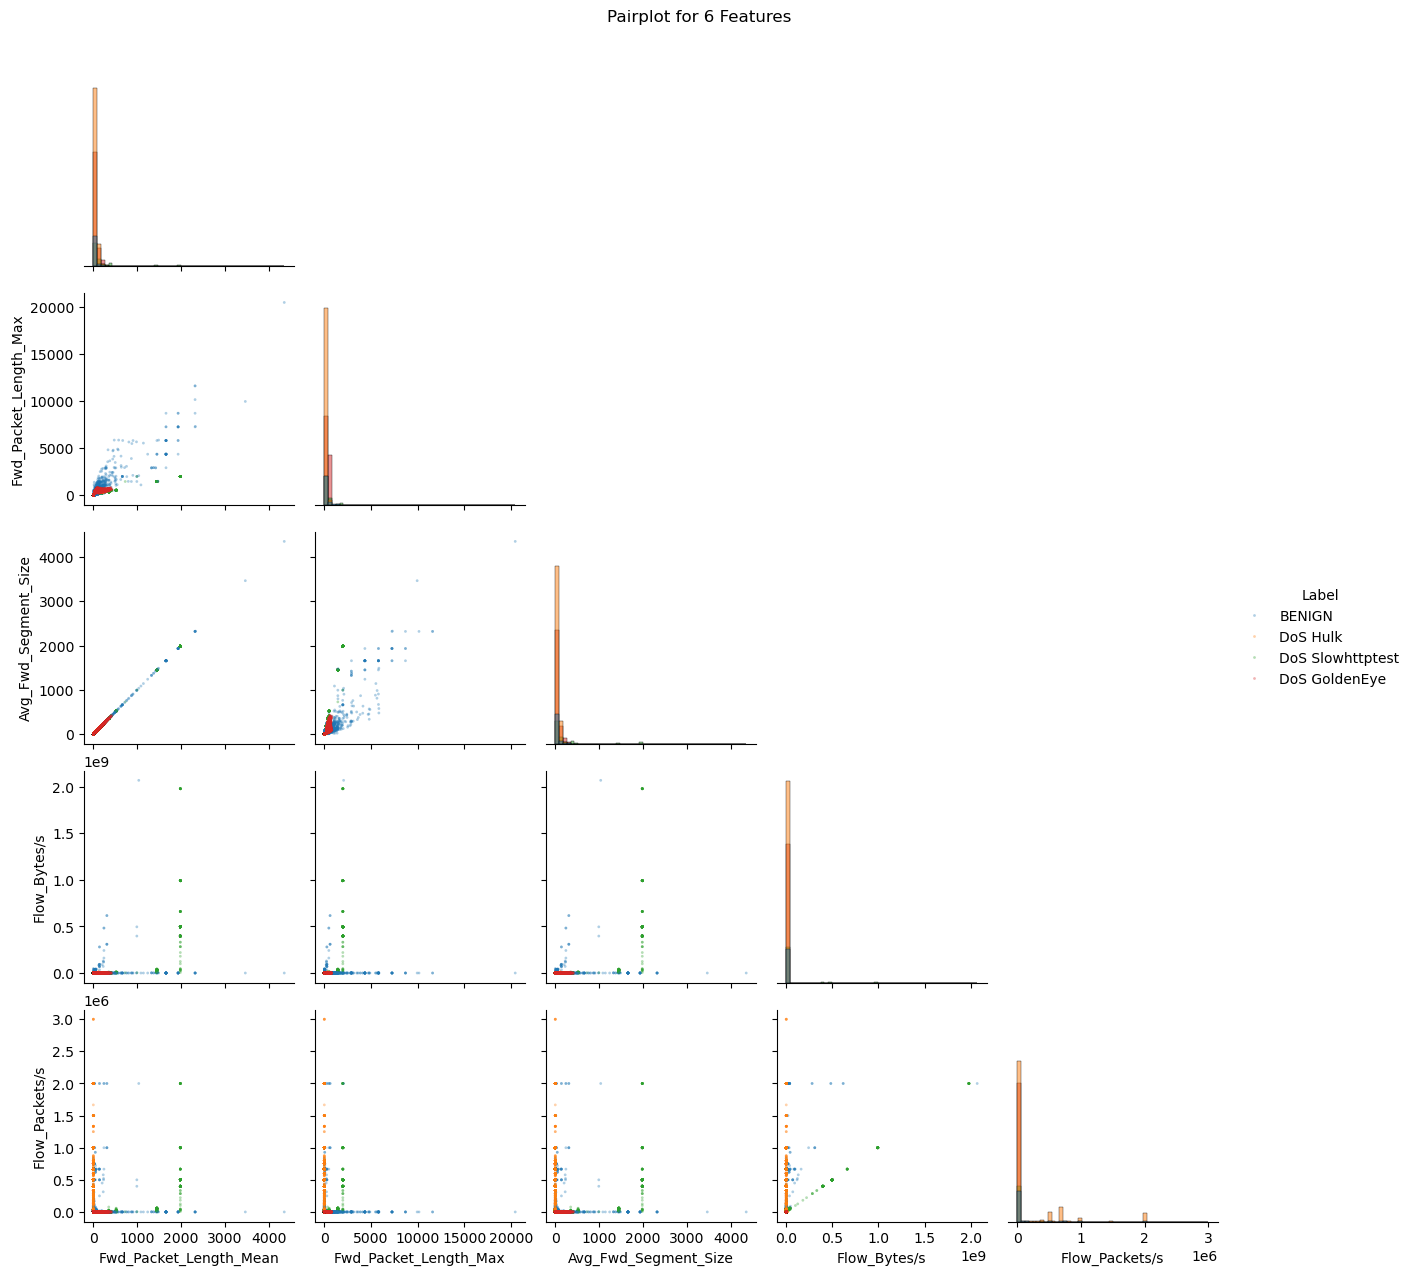

In [ ]:
import seaborn as sns
 
import matplotlib.pyplot as plt
 
selected = [
 
    "Fwd_Packet_Length_Mean",
 
    "Fwd_Packet_Length_Max",
 
    "Avg_Fwd_Segment_Size",
 
    "Flow_Bytes/s",
 
    "Flow_Packets/s",
 
    "Label"
 
]
 
pairgrid = sns.pairplot(
 
    df[selected],
 
    hue="Label",
   
    kind = "scatter",
 
    diag_kind="hist",
 
    corner=True,
 
    plot_kws={"alpha": 0.35, "s": 8, "edgecolor": "none", "s": 4, "rasterized": True},
 
    diag_kws = {"bins": 50}
)
 
pairgrid.fig.suptitle("Pairplot for 6 Features", y=1.02)
 
pairgrid.savefig("../eda/figures/bivariate/pairplot6feat.png", dpi=180)
 
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("../data/cleaned/wednesday_cleaned.csv")

# Get all numeric columns (exclude Label and Attack)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['Attack']]

print(f"\nNumeric features to standardize: {len(numeric_cols)}")

# Standardize the numeric columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_cols])

# Convert back to DataFrame with column names
df_standardized = pd.DataFrame(df_scaled, columns=numeric_cols)

# Add back the target column
df_standardized['Attack'] = df['Attack'].values

print("\nFirst few rows:")
print(df_standardized.head())



Numeric features to standardize: 67

First few rows:
   Destination_Port  Flow_Duration  Total_Fwd_Packets  Total_Backward_Packets  \
0         -0.055155      -0.980633          -0.068553               -0.033973   
1         -0.055155      -0.982667          -0.054467               -0.044437   
2         -0.123165      -0.980467          -0.068553               -0.033973   
3         -0.123165      -0.982675          -0.054467               -0.023509   
4         -0.110958       0.636370          -0.054467               -0.023509   

   Total_Length_of_Fwd_Packets  Total_Length_of_Bwd_Packets  \
0                    -0.212452                    -0.032955   
1                    -0.212452                    -0.032955   
2                    -0.181534                    -0.031423   
3                    -0.166075                    -0.031840   
4                    -0.159450                    -0.032520   

   Fwd_Packet_Length_Max  Fwd_Packet_Length_Min  Fwd_Packet_Length_Mean  \
0    

In [ ]:
from sklearn.cluster import KMeans

# Perform K-means clustering with k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_standardized[numeric_cols])

# Add cluster labels to dataframe
df_standardized['Cluster'] = cluster_labels

print(f"K-means clustering complete!")
print(f"\nCluster distribution:")
print(df_standardized['Cluster'].value_counts())

print(f"\nFirst few rows:")
print(df_standardized.head(10))

K-means clustering complete!

Cluster distribution:
Cluster
0    39651
1    21350
Name: count, dtype: int64

First few rows:
   Destination_Port  Flow_Duration  Total_Fwd_Packets  Total_Backward_Packets  \
0         -0.055155      -0.980633          -0.068553               -0.033973   
1         -0.055155      -0.982667          -0.054467               -0.044437   
2         -0.123165      -0.980467          -0.068553               -0.033973   
3         -0.123165      -0.982675          -0.054467               -0.023509   
4         -0.110958       0.636370          -0.054467               -0.023509   
5          8.457728      -0.982679          -0.054467               -0.044437   
6          7.749382       1.350157           0.001875                0.018347   
7         -0.123165      -0.981236          -0.068553               -0.033973   
8         -0.123165      -0.981118          -0.054467               -0.023509   
9         -0.055155      -0.980713           0.015960            

In [ ]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score, accuracy_score

print("="*70)
print("COMPARING CLUSTERS VS TRUE LABELS")
print("="*70)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(df_standardized['Attack'], df_standardized['Cluster'])
print(cm)
print("\nInterpretation:")
print(f"  True Benign (0) assigned to Cluster 0: {cm[0,0]}")
print(f"  True Benign (0) assigned to Cluster 1: {cm[0,1]}")
print(f"  True Attack (1) assigned to Cluster 0: {cm[1,0]}")
print(f"  True Attack (1) assigned to Cluster 1: {cm[1,1]}")

# Cross-tabulation
print("\n\nCross-tabulation (True Label vs Cluster):")
crosstab = pd.crosstab(df_standardized['Attack'], df_standardized['Cluster'], 
                        rownames=['True Label'], colnames=['Cluster'])
print(crosstab)

# Adjusted Rand Index
ari = adjusted_rand_score(df_standardized['Attack'], df_standardized['Cluster'])
print(f"\n\nAdjusted Rand Index: {ari:.4f}")
print("(1.0 = perfect match, 0.0 = random, negative = worse than random)")

# Calculate accuracy (assuming best alignment)
# Try both mappings: 0->0,1->1 and 0->1,1->0
acc1 = accuracy_score(df_standardized['Attack'], df_standardized['Cluster'])
acc2 = accuracy_score(df_standardized['Attack'], 1 - df_standardized['Cluster'])
best_acc = max(acc1, acc2)

print(f"\nBest Clustering Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

COMPARING CLUSTERS VS TRUE LABELS

Confusion Matrix:
[[ 4822   175]
 [34829 21175]]

Interpretation:
  True Benign (0) assigned to Cluster 0: 4822
  True Benign (0) assigned to Cluster 1: 175
  True Attack (1) assigned to Cluster 0: 34829
  True Attack (1) assigned to Cluster 1: 21175


Cross-tabulation (True Label vs Cluster):
Cluster         0      1
True Label              
0            4822    175
1           34829  21175


Adjusted Rand Index: -0.0439
(1.0 = perfect match, 0.0 = random, negative = worse than random)

Best Clustering Accuracy: 0.5738 (57.38%)


What does this show us?

- K-means with k=2 doesn't work well for this dataset
- The natural clustering in the data doesn't match the benign/attack split

PCA ANALYSIS

Variance explained by PC1: 0.2030 (20.30%)
Variance explained by PC2: 0.1394 (13.94%)
Total variance explained by 2 components: 0.3424 (34.24%)


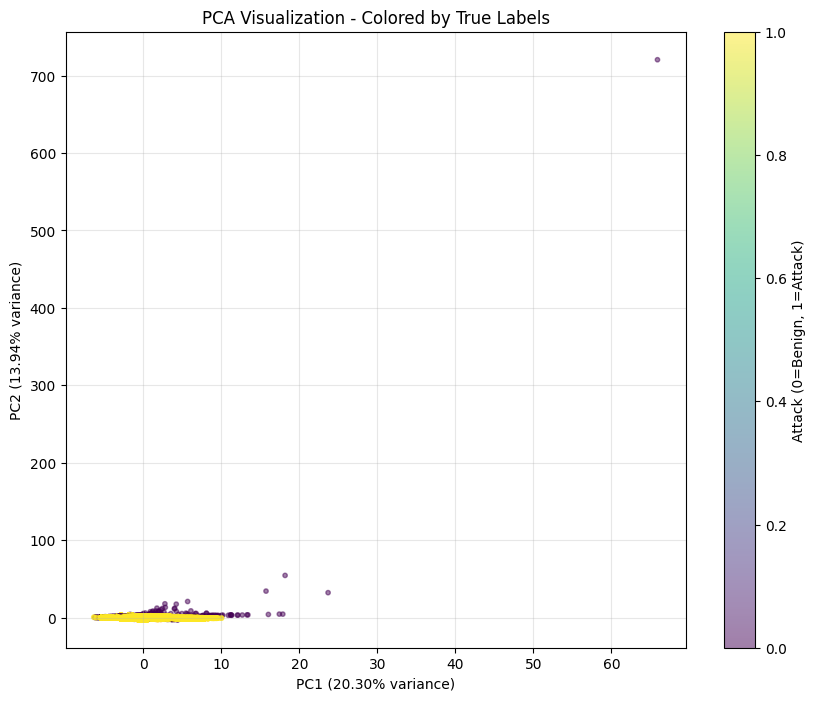

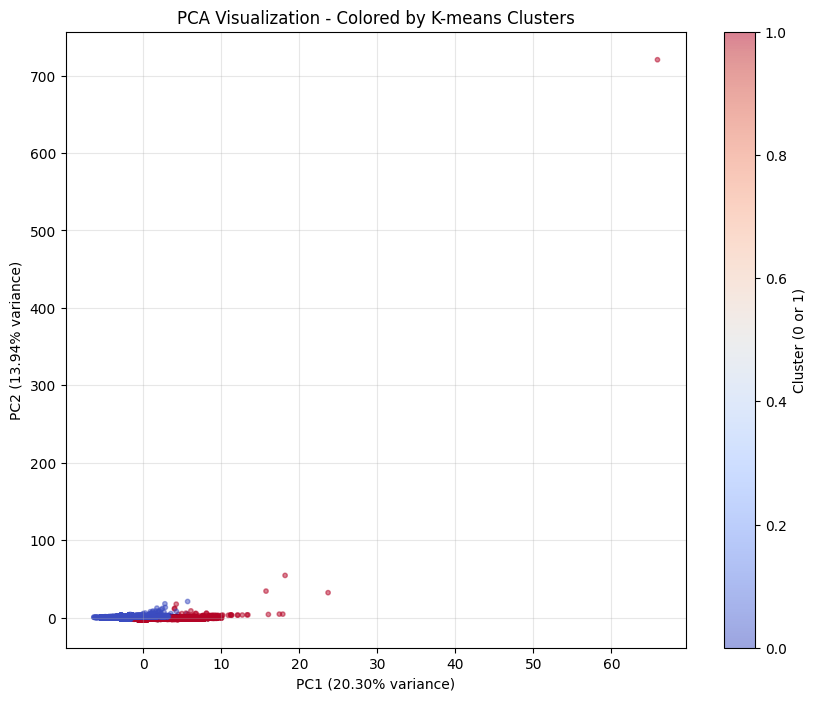

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_standardized[numeric_cols])

# Add PCA components to dataframe
df_standardized['PC1'] = pca_result[:, 0]
df_standardized['PC2'] = pca_result[:, 1]

print("="*70)
print("PCA ANALYSIS")
print("="*70)

# Show variance explained
print(f"\nVariance explained by PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

# Create output directory
import os
os.makedirs('../eda/figures/multivariate', exist_ok=True)

# Plot 1: Colored by True Labels (Attack)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_standardized['PC1'], df_standardized['PC2'], 
                     c=df_standardized['Attack'], cmap='viridis', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('PCA Visualization - Colored by True Labels')
plt.colorbar(scatter, label='Attack (0=Benign, 1=Attack)')
plt.grid(alpha=0.3)
plt.savefig('../eda/figures/multivariate/pca_true_labels.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Colored by K-means Clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_standardized['PC1'], df_standardized['PC2'], 
                     c=df_standardized['Cluster'], cmap='coolwarm', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('PCA Visualization - Colored by K-means Clusters')
plt.colorbar(scatter, label='Cluster (0 or 1)')
plt.grid(alpha=0.3)
plt.savefig('../eda/figures/multivariate/pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


12/8/2025 - Nafisa - Multivariate Analysis

**Purpose:**  
Perform multivariate exploratory data analysis to understand relationships between features, evaluate K means(k=2) clustering, and assess dimensionality reduction techniques for potential use in modeling.

**Interpretation / Findings:** 

**Data Preparation:**
- Standardized 67 numeric features (mean=0, std=1)
- Final dataset: 60,995 rows with binary target (0=Benign, 1=Attack)

**K-means Clustering (k=2):**
- Attempted unsupervised clustering to see if data naturally separates into attack/benign groups
- Adjusted Rand Index: -0.0439 
- Clustering Accuracy: 57.38% 
- **Confusion Matrix:**
  - Cluster 0: 34,829 attacks + 4,822 benign
  - Cluster 1: 21,175 attacks + 175 benign

**PCA Analysis:**
- 2 components explain only 34% variance (66% information loss)
- Heavy overlap between attacks and benign traffic in visualizations
- Would need 17+ components for 90% variance 


**Notes for Team:**
- **Figures saved to:** `eda/figures/multivariate/`
  - `pca_true_labels.png` - PCA colored by actual attack/benign labels
  - `pca_clusters.png` - PCA colored by K-means cluster assignments

### Done with Task

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# load the data
df = pd.read_csv('../data/cleaned/wednesday_cleaned.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (61001, 69)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Attack
0,443,87261,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,443,523,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,53,94304,1,1,56,338,56,56,56.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,53,207,2,2,84,246,42,42,42.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,123,69022032,2,2,96,96,48,48,48.0,0.0,...,22276.0,0.0,22276,22276,69000000.0,0.0,69000000,69000000,BENIGN,0


In [ ]:
# separate X and y
# Attack is the binary target
X = df.drop(['Label', 'Attack'], axis=1)
y = df['Attack']

print(f'Features: {X.shape}')
print(f'Target: {y.shape}')
print(y.value_counts())

Features: (61001, 67)
Target: (61001,)
Attack
1    56004
0     4997
Name: count, dtype: int64


In [ ]:
# split into train and test
# 80% train, 20% test
# stratify to keep class ratio the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:')
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print('\nTest:')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

Train:
X_train: (48800, 67)
y_train: (48800,)

Test:
X_test: (12201, 67)
y_test: (12201,)


In [ ]:
# make sure both sets have similar attack percentages
print('Train:')
print(y_train.value_counts())
train_attack_pct = (y_train.sum() / len(y_train)) * 100
print(f'{train_attack_pct:.2f}% attacks')

print('\nTest:')
print(y_test.value_counts())
test_attack_pct = (y_test.sum() / len(y_test)) * 100
print(f'{test_attack_pct:.2f}% attacks')

# looks good, both around 91%

Train:
Attack
1    44802
0     3998
Name: count, dtype: int64
91.81% attacks

Test:
Attack
1    11202
0      999
Name: count, dtype: int64
91.81% attacks


In [ ]:
# standardize the features
# important: only fit on training data
scaler = StandardScaler()
scaler.fit(X_train)

# now transform both sets using training stats
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('done scaling')
print(X_train_scaled.shape)
print(X_test_scaled.shape)

done scaling
(48800, 67)
(12201, 67)


In [ ]:
# check that the mean and std are around 0 and 1
print('train mean:', X_train_scaled.mean(axis=0).mean())
print('train std:', X_train_scaled.std(axis=0).mean())

print('\ntest mean:', X_test_scaled.mean(axis=0).mean())
print('test std:', X_test_scaled.std(axis=0).mean())

train mean: -5.053728688555522e-18
train std: 1.0

test mean: 0.003578225234745424
test std: 0.875324614155965


In [ ]:
# convert back to dataframes so we can use column names later
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(X_train_scaled_df.shape)
print(X_test_scaled_df.shape)
X_train_scaled_df.head()

(48800, 67)
(12201, 67)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
46742,-0.117964,1.030309,0.026174,0.006278,-0.005178,0.016720,0.356036,-0.098527,-0.104191,0.251334,...,-0.008792,0.421318,-0.269137,-0.077088,-0.270303,-0.258364,1.143699,-0.187801,1.119083,1.154696
45086,-0.117964,-0.977820,-0.049470,-0.040558,-0.248416,-0.030319,-0.821252,-0.098527,-0.424007,-0.852963,...,-0.021609,0.421318,-0.270396,-0.077088,-0.271495,-0.259649,-0.856346,-0.187801,-0.878047,-0.831812
30604,-0.117964,1.030034,0.038781,0.015645,0.012382,0.016720,0.441027,-0.098527,-0.119203,0.263341,...,-0.008792,0.421318,-0.269770,-0.077088,-0.270903,-0.259011,1.122646,-0.187801,1.098061,1.133785
25896,-0.117964,1.546237,-0.049470,-0.031191,-0.067613,-0.030295,0.053844,-0.098527,0.526890,0.788719,...,-0.008792,0.421318,-0.270396,-0.077088,-0.271495,-0.259649,1.670027,-0.187801,1.644644,1.677461
32168,-0.117964,-0.977796,-0.011648,-0.040558,-0.248416,-0.030319,-0.821252,-0.098527,-0.424007,-0.852963,...,-0.021609,0.421318,-0.270396,-0.077088,-0.271495,-0.259649,-0.856346,-0.187801,-0.878047,-0.831812


12/4/2025 - Umar

did train test split (80/20) with stratify so class balance is same in both sets. got 48800 train samples and 12201 test. attack percentage is around 91.8% in both which is good

applied standardscaler to the features - fitted it only on training data to avoid leakage. then used same scaler to transform test data. checked the means and stds and they look right (train is basically 0 and 1, test is close but not exact)

data is ready for modeling now

### Done with Task

12/4/2025 - Moosa

Created 3 functions to be used across our modeling workflow:

1. fit_model(model, X_train, y_train): Trains any scikit-learn model and returns it.

2. evaluate_model(model, X_test, y_test): Tests the model on unseen data and prints the confusion matrix and classification report.

3. save_model(model, path)

Saves a trained model as a .pkl file so it can be loaded later again.

These functions will be used for models in the training and deployment steps.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pickle

def fit_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n")
    print(cm)

    report = classification_report(y_test, y_pred)
    print("\nClassification Report:\n")
    print(report)

    return cm, report

def save_model(model, path):
    with open(path, "wb") as f:
        pickle.dump(model, f)

    print(f"Model saved to {path}")

Some context about Pickle for the team:
This is module that converts an object (like a trained machine-learning model) into a binary file so it can be saved and loaded later. Saving a model with pickle will let us use it again during deployment without retraining. When the API starts, just load the .pkl file and make the predictions. Hope this helps!

## Task Complete


In [ ]:
import json

# Get Umar's fitted scaler and extract its parameters
scaler_params = {
    "scaler_type": "StandardScaler",
    "feature_means": scaler.mean_.tolist(),      # Mean for each feature
    "feature_stds": scaler.scale_.tolist(),       # Std for each feature  
    "feature_names": X_train.columns.tolist()     # Feature names in order
}

# Load existing final_features.json 
with open('../data/final_features.json', 'r') as f:
    final_features = json.load(f)

# Add the TRAINING scaler parameters as a new section
final_features['scaler_params'] = scaler_params

# Save it back
with open('../data/final_features.json', 'w') as f:
    json.dump(final_features, f, indent=2)


12/8/2025 - Nafisa - Scaling Parameter Storage

**What I Did:**
- Extracted mean and std from Umar's fitted StandardScaler
- Saved scaler parameters to `../data/final_features.json` under `scaler_params`

**Why:**
- Deployment requires same scaling parameters as training data
- Prevents incorrect predictions from inconsistent scaling

### Done with Task

12/8/2025 - Nafisa - Saved Models

**What I Did:**
- Naming Convention: `{model_name}.pkl`
- All trained models saved to `models/saved_models/`:
    - naive_bayes.pkl
    - knn.pkl
    - logistic_regression.pkl
    - random_forest.pkl
    - decision_tree.pkl
    - svm.pkl
- These can be loaded later using Python's pickle module for evaluation or deployment.


**Notes for team:**
- Moosa had already saved the models using a function he created. Umar had implemented the code for saving the models in `train_simple.ipynb`. I executed his code to save all the models in the specified directory.

### Done with Task

12/6/2025 - Moosa

Purpose: The goal is to understand how each model performs on unseen data and save all evaluation outputs to the correct project folders for team reference and presentation.

In [ ]:
import sys; 
import pandas as pd
import pickle
import os
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sys.path.append("../../") #To allow imports from parent folders

# Load
df = pd.read_csv("../data/cleaned/wednesday_cleaned.csv")
X = df.drop(['Label', 'Attack'], axis=1)
y = df['Attack']

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale test set
scaler = StandardScaler()
scaler.fit(X_train)
X_test_scaled = scaler.transform(X_test)

# Models loading
models = {
    "random_forest": "../models/saved_model/random_forest.pkl",
    "decision_tree": "../models/saved_model/decision_tree.pkl",
    "svm": "../models/saved_model/svm.pkl"
}

loaded = {}
for name, path in models.items():
    with open(path, "rb") as f:
        loaded[name] = pickle.load(f)

# Output folders
os.makedirs("../models/evaluation/confusion_matrices", exist_ok=True)
os.makedirs("../models/evaluation/metrics_tables", exist_ok=True)

# Evaluate and save outputs
for name, model in loaded.items():
    print(f"\n{name.upper()} \n")

    y_pred = model.predict(X_test_scaled)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    with open(f"../models/evaluation/confusion_matrices/{name}_cm.txt", "w") as f:
        f.write(str(cm))

    # Classification report
    report = classification_report(y_test, y_pred)
    print("\nClassification Report:\n", report)

    with open(f"../models/evaluation/metrics_tables/{name}_report.txt", "w") as f:
        f.write(report)

print("\nAll evaluations completed and saved!!")


/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.1 


RANDOM_FOREST 


Confusion Matrix:
 [[  998     1]
 [    1 11201]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       1.00      1.00      1.00     11202

    accuracy                           1.00     12201
   macro avg       1.00      1.00      1.00     12201
weighted avg       1.00      1.00      1.00     12201


DECISION_TREE 


Confusion Matrix:
 [[  996     3]
 [    2 11200]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       1.00      1.00      1.00     11202

    accuracy                           1.00     12201
   macro avg       1.00      1.00      1.00     12201
weighted avg       1.00      1.00      1.00     12201


SVM 


Confusion Matrix:
 [[  943    56]
 [    5 11197]]

Classification Report:
               precision    recall  f1-score   support

           0       0.9

Evaluated three complex models (Random Forest, Decision Tree, and SVM) using the test set and generated both confusion matrices and classification reports. All models performed extremely well overall, with Random Forest achieving perfect accuracy and the other two models showing only a few misclassifications. 

The confusion matrices were saved in models/evaluation/confusion_matrices/ and the classification reports were saved in models/evaluation/metrics_tables/ for the team to use in later steps.

## Task Complete

---

12/6/2025 - Umar

generating performance summary table for all models

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

all_models = loaded.copy()  

# load simple models
nb_path = '../models/saved_model/naive_bayes.pkl'
knn_path = '../models/saved_model/knn.pkl'
lr_path = '../models/saved_model/logistic_regression.pkl'

with open(nb_path, 'rb') as f:
    all_models['naive_bayes'] = pickle.load(f)
print('loaded naive bayes')

with open(knn_path, 'rb') as f:
    all_models['knn'] = pickle.load(f)
print('loaded knn')

with open(lr_path, 'rb') as f:
    all_models['logistic_regression'] = pickle.load(f)
print('loaded logistic regression')

print(f'total: {len(all_models)} models')

loaded naive bayes
loaded knn
loaded logistic regression
total: 6 models


In [ ]:
# calculate metrics accuracy, recall, f1, auc
performance_data = []

for model_name, model in all_models.items():
    preds = model.predict(X_test_scaled)
    
    # need probabilities for auc
    # some models have predict_proba, svm uses decision_function
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, proba)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test_scaled)
        auc = roc_auc_score(y_test, scores)
    else:
        auc = None  
    
    # calculate other metrics
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    performance_data.append({
        'model': model_name,
        'accuracy': acc,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': auc
    })
    
    print(f'{model_name}: acc={acc:.4f}, rec={rec:.4f}, f1={f1:.4f}, auc={auc:.4f}')

# make dataframe
df_results = pd.DataFrame(performance_data)

# sort by f1 score
df_results = df_results.sort_values('f1_score', ascending=False)

print('\nPerformance Summary:')
print(df_results)

random_forest: acc=0.9998, rec=0.9999, f1=0.9999, auc=1.0000
decision_tree: acc=0.9996, rec=0.9998, f1=0.9998, auc=0.9984


/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/usid/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feat

svm: acc=0.9950, rec=0.9996, f1=0.9973, auc=0.9979
naive_bayes: acc=0.9826, rec=0.9878, f1=0.9905, auc=0.9718
knn: acc=0.9989, rec=0.9995, f1=0.9994, auc=0.9979
logistic_regression: acc=0.9937, rec=0.9998, f1=0.9966, auc=0.9966

Performance Summary:
                 model  accuracy    recall  f1_score   roc_auc
0        random_forest  0.999836  0.999911  0.999911  0.999991
1        decision_tree  0.999590  0.999821  0.999777  0.998409
4                  knn  0.998935  0.999464  0.999420  0.997900
2                  svm  0.995000  0.999554  0.997283  0.997864
5  logistic_regression  0.993689  0.999821  0.996574  0.996625
3          naive_bayes  0.982624  0.987770  0.990511  0.971785


In [ ]:
# save to csv
save_path = '../models/evaluation/metrics_tables/performance_summary.csv'
df_results.to_csv(save_path, index=False)
print(f'saved to {save_path}')

saved to ../models/evaluation/metrics_tables/performance_summary.csv


Performance summary table is done. All 6 models evaluated. 

All models have high AUC (>0.98) so they can distinguish dos attacks from benign traffic well.

Table saved as csv in metrics_tables folder.

[2025-12-09] - [Emil] - [Skeleton API Deployment]

**What I worked on:**
- I implemented `/deployment/app.py` utilizing the FastAPI framework to build a service that accepts feature vectors as input and returns a prediction of DoS or benign traffic.
- The best performing model was trained and saved to disk as a `.pkl` file - this model was `random_forest.pkl`.  

Below is the code stored in the `deployment/app.py` file:

```
from fastapi import FastAPI, HTTPException
import joblib
from pathlib import Path
import sys

# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from deployment.schema_loader import load_schema
from deployment.preprocessing import Preprocessor

# First we create a new FastAPI object
app = FastAPI(
    title = "DoS Classifier API",
    version = "0.1.0",
    description = "API for predicting DoS attacks vs. benign traffic"
)

# Load the schema
SCHEMA_PATH = Path(project_root / "data/final_features.json")
schema = load_schema(SCHEMA_PATH)

# Then we create the preprocessor object.
preprocessor = Preprocessor(schema_path = SCHEMA_PATH)

# Load the trained model
MODEL_PATH = Path("models/saved_model/random_forest.pkl")

# This logic is required because as of the writing of this code, no model has been trained. 
if MODEL_PATH.exists():
    model = joblib.load(MODEL_PATH)
else:
    model = None

# Implementation of health check endpoint
@app.get("/health")
def health_check():
    return {"status": "ok"}

# Implementation of version endpoint
@app.get("/version")
def version():
    return {"api_version": "0.1.0"}

# Implementation of prediction endpoint (inference not yet implemented)
@app.post("/predict")
def predict(input_data: dict):
    # Running preprocessing with sanity checking.
    try:
        X = preprocessor.preprocess_input(input_data)
    except Exception as e:
        raise HTTPException(
            status_code = 400, 
            detail = f"Failed to preprocess input data: {e}"
        )
    try:
        y_pred = model.predict(X)
    except Exception as e:
        raise HTTPException(
            status_code = 500, 
            detail = f"Failed to make predictions: {e}"
        )
    return {"prediction": int(y_pred[0])}
```

**Interpretation / Findings:**  
In this script, the deployment layer is implemented of our intrusion-detection classifier. It loads the project's `final_features.json` schema and the best-performing trained model to create a reproducible inference pipeline. Incoming rquests to the `/predict` endpoint are validated to ensure correct feature names, types, and ordering. The API then applies the same preprocessing steps used in training, passes the transformed input to the loaded classifier, and returns the predicted class label. I also implemented two endpoints, `/health` and `/version`, which serve as health checks and version endpoints, respectively - entirely diagnostic. 

**Notes for Team:**  
This is testable code - we can begin to write unit/Postman tests.

### Done with Task

[2025-12-09] - [Emil] - [Preprocessing for API]

**What I worked on:**
- I implemented the `preprocess_input` method in the `Preprocessor` class to transform incoming feature vectors into a format that can be consumed by the trained model. This file is found in `deployment/preprocessing.py`.
- I implemented the `load_schema` method in the `schema_loader.py` file to load the project's `final_features.json` schema.

Below is the code stored in the `deployment/preprocessing.py` file:

```
import json
import numpy as np
from pathlib import Path

class Preprocessor:
    def __init__(self, schema_path: str):
        """
        Instantiator method for the preprocessor class. 
        
        :param self: This object.
        :param schema_path: The path to the final_features.json file.
        """
        self.schema_path = Path(schema_path)

        # First we need to load the schema
        with open(self.schema_path, "r") as f:
            schema = json.load(f)
        
        # Then we need to extract the scaler parameters from final_features.json
        scaler_params = schema["scaler_params"]

        self.feature_names = scaler_params["feature_names"]
        self.feature_means = np.array(scaler_params["feature_means"], dtype = float)
        self.feature_stds = np.array(scaler_params["feature_stds"], dtype = float)

        # Sanity check to ensure the feature names, means, and stds are the same length
        if len(self.feature_names) != len(self.feature_means) or len(self.feature_names) != len(self.feature_stds):
            raise ValueError("Feature names, means, and stds are not the same length")

        # Convert the numeric types to a dictionary for faster lookup. 
        self.numeric_types = {
            k: v["dtype"]
            for k, v in schema.items()
            if isinstance(v, dict) and v.get("feature_type") == "numeric" and not k.startswith("_") and k != "scaler_params"
        }
        
        self.n_features = len(self.feature_names)

    def validate_input(self, sample: dict):
        # Check for missing fields. 
        for f in self.feature_names:
            if not f in sample:
                raise ValueError(f"Missing feature {f}")
        
        # Check for unexpected fields.
        for k in sample.keys():
            if k not in self.feature_names:
                raise ValueError(f"Unexpected feature {k}")
        
        # Validate the numeric types.
        for key, value in sample.items():

            # Raise exception if the value is null.
            if value is None:
                raise ValueError(f"Field '{key}' cannot be null.")
            
            # Try to typecast the value to numeric, otherwise raise exception.
            if not isinstance(value, (int, float)):
                try:
                    sample[key] = float(value)
                except:
                    raise ValueError(f"Field '{key}' must be numeric, but value is '{value}' with type {type(value)}.")
                
        return sample
    
    def safe_scaling(self, X):
        """
        Safely scales the dataset by avoiding divide by zero errors.
        
        :param self: This object.
        :param X: The dataset to be scaled (numpy array). 
        """
        # If the std is too small, replace it with 1.0
        safe_stds = np.where(self.feature_stds < 1e-12, 1.0, self.feature_stds)

        # Apply the scaling.
        return (X - self.feature_means) / safe_stds

    def preprocess_input(self, sample: dict):
        """
        Takes a dictionary containing raw feature inputs
        and returns a (1, n_features) scaled numpy array. 

        Missing features are filled with 0.0.
        
        :param self: This object.
        :param sample: The dictionary containing raw feature inputs.
        """
        # First validate the input
        sample = self.validate_input(sample)

        # Then order the features.
        ordered = [sample[f] for f in self.feature_names]

        # Then we convert to a dataframe and scale and reshape the array for prediction.
        X = np.array(ordered, dtype = float).reshape(1, -1)
        
        # Apply scaling.
        X_scaled = self.safe_scaling(X)

        return X_scaled
```

Below is the code stored in the `deployment/schema_loader.py` file:
```
import json
from pathlib import Path

def load_schema(schema_path: Path):
    """
    Loads the project's `final_features.json` schema.

    :param schema_path: Path to the schema file.
    """
    schema_path = Path(schema_path)

    # Check if the schema_path exists.
    if not schema_path.exists():
        raise FileNotFoundError(f"Schema file not found at {schema_path}")

    with open(schema_path, "r") as f:
        schema = json.load(f)

    # Added sanity checking to ensure all keys are present.
    required_sections = ["scaler_params", "_metadata"]
    for section in required_sections:
        if section not in schema:
            raise KeyError(f"Required section '{section}' not found in schema")

    # Validating if length of scaling arrays match length of feature list.
    scaler = schema["scaler_params"]
    if not (len(scaler["feature_names"]) == len(scaler["feature_means"]) == len(scaler["feature_stds"])):
        raise ValueError("Length of scaling arrays does not match length of feature list")

    return schema
```

**Interpretation / Findings:**  
The preprocessor class is responsible for enforcing strict input validation and for preparing incoming JSON data for inference. When a request arrives at the `/predict` endpoint, the preprocessor loads the project's feature schema stored in `final_features.json`. We do this to make sure that input contains all expected features, includes no unexpected features, and every value is numeric and non-null (performing coercion where possible). After validation, features are reordered to exactly match layout used during model training. The preprocessor then applies the same scaling applied during training. The entire preprocessing pipeline then returns a NumPy array ready to be passed into the trained model. The schema loader function is responsible for loading the project's `final_features.json` schema. It includes some sanity checking to ensure all keys are present and that the length of the scaling arrays match the length of the feature list.

**Notes for Team:**  
Also testable code!!!

[2025-12-09] - [Emil] - [Deployment Tests]

**What I worked on:**  
- I implemented in the code below some edge cases to validate that the preprocessing pipeline works as expected.

In [ ]:
import sys
from pathlib import Path
# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from deployment.preprocessing import Preprocessor
from deployment.schema_loader import load_schema
import pandas as pd


# Load the schema
schema_path = project_root / "data" / "final_features.json"
schema = load_schema(schema_path)

# Create the preprocessor object
preprocessor = Preprocessor(schema_path)

# Load an example feature vector from the cleaned dataset
df = pd.read_csv(project_root / "data" / "cleaned" / "wednesday_cleaned.csv")
# Get a sample feature vector, dropping the labels.
sample = df.iloc[0].drop(labels = ["Label", "Attack"]).to_dict()

# Testing preprocessing works as expected.
    # This should return 2D array with correct scaling with NaN's removed.
X = preprocessor.preprocess_input(sample)
print(X[:5])
print(X.shape)

# Testing Edge Case 1: Missing Feature
    # We copy the sample and remove the "Flow_Duration" feature
    # This should fail
sample_missing = sample.copy()
sample_missing.pop("Flow_Duration")
try:
    preprocessor.preprocess_input(sample_missing)
except Exception as e:
    print(f"Edge Case 1: Missing Feature passed: {e}")
else:
    print("Edge Case 1: Missing Feature failed.")

# Testing Edge Case 2: Extra Feature
    # We copy the sample and add an extra feature
    # This should fail
sample_extra = sample.copy()
sample_extra["FakeFeature"] = 999
try:
    preprocessor.preprocess_input(sample_extra)
except Exception as e:
    print(f"Edge Case 2: Extra Feature passed: {e}")
else:
    print("Edge Case 2: Extra Feature failed.")

# Testing Edge Case 3: Wrong Data Type
    # We copy the sample and change the data type of a feature
    # This should fail
sample_wrong_type = sample.copy()
sample_wrong_type["Flow_Duration"] = "not_a_number"
try:
    preprocessor.preprocess_input(sample_wrong_type)
except Exception as e:
    print(f"Edge Case 3: Wrong Data Type passed: {e}")
else:
    print("Edge Case 3: Wrong Data Type failed.")

# Testing Edge Case 4: Null Values
    # We copy the sample and change the feature to null
    # This should fail
sample_null = sample.copy()
sample_null["Flow_Duration"] = None
try:
    preprocessor.preprocess_input(sample_null)
except Exception as e:
    print(f"Edge Case 4: Null Values passed: {e}")
else:
    print("Edge Case 4: Null Values failed.")

[[-5.44523491e-02 -9.75796567e-01 -6.20770529e-02 -3.11910947e-02
  -2.48415997e-01 -3.03189749e-02 -8.21251603e-01 -9.85274740e-02
  -4.24007280e-01 -8.52963483e-01 -1.03045482e+00 -1.68394212e-01
  -1.09424950e+00 -1.00476992e+00 -5.19354910e-02 -2.93954970e-01
  -4.78955371e-01 -7.58748902e-01 -8.94945340e-01 -2.39048250e-01
  -9.30067756e-01 -5.88177393e-01 -7.50651742e-01 -8.89878521e-01
  -2.72550196e-01 -4.70992203e-01 -3.89044269e-01 -4.07976751e-01
  -4.27896037e-01 -7.24757718e-02 -1.40827541e-01 -9.59468238e-02
  -4.81206968e-02 -2.90839820e-01 -7.09344991e-02 -1.35858737e-01
  -1.04834806e+00 -1.15693452e+00 -1.09080540e+00 -8.36777120e-01
  -3.82025401e-01 -1.40827541e-01 -6.40197519e-03 -7.53004386e-01
   1.05304432e+00  6.64090834e+00 -6.40197519e-03  1.36670283e+00
  -1.15369665e+00 -4.24007280e-01 -1.09424950e+00 -6.20770529e-02
  -2.48415997e-01 -3.11910947e-02 -3.03177243e-02 -7.36217347e-01
  -6.96324672e-02 -2.16092942e-02  4.21317660e-01 -2.70395753e-01
  -7.70878

**Interpretation/Findings:**  
Here I correctly imported modules required from the rest of the project. While I won't go back and correct work, figuring out how to correctly import modules using a jupyter notebook was tricky and I saw that other notebooks simply reimplemented code that was put in other python scripts. But in the end, we got the same result - just lost some of the intended modularity. This script evaluates whether the deployed preprocessing pipeline behaves consistently with the training pipeline and enforces the constraints correctly. It loads the project's schema and initializes a `Preprocessor` object, ensuring transformations use the same feature order, data types, and scaling parameters established during training. Using a real row from the cleaned dataset, the script verifies that array is 2D and scaled appropriately. We also put in four edge-case tests to verify detection of missing features, unexpected features, wrong data types, and null values. These tests ensure that the pipeline detects malformed or incomplete inputs. 

[2025-12-09] - [Emil] - [Postman Tests]

**What I worked on:**  
- I generated representative samples for both attack and benign samples from the dataset. These samples allow us to test the `/predict` endpoint with Postman. 
- In the below code, I randomly select a benign and attack sample from the cleaned dataset.

The vectors are saved in `deployment/sample_requests/benign_sample.json` and `deployment/sample_requests/attack_sample.json` respectively. The code to generate those files is below. In that code, we first filter based on the label (either BENIGN or if the string contains DoS), randomly sample (with a set random state for reproducible selection), then remove columns for attack and label, convert the 1-row dataframe to a Series and finally convert to a dictionary.

In [ ]:
import sys
from pathlib import Path
import json
# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

# Load an example feature vector from the cleaned dataset
df = pd.read_csv(project_root / "data" / "cleaned" / "wednesday_cleaned.csv")
benign_sample = df[df["Label"] == "BENIGN"].sample(1, random_state=42).drop(columns=["Label", "Attack"]).iloc[0].to_dict()
attack_sample = df[df["Label"].str.contains("DoS")].sample(1, random_state=42).drop(columns=["Label", "Attack"]).iloc[0].to_dict()

# Save to .json files.
with open(project_root / "deployment" / "sample_requests" / "benign_sample.json", "w") as f:
    json.dump(benign_sample, f, indent=2)
with open(project_root / "deployment" / "sample_requests" / "attack_sample.json", "w") as f:
    json.dump(attack_sample, f, indent=2)

Again, the data used to test the API is found in the `deployment/sample_requests` directory.

To test the `/predict` endpoint and other endpoints yourself, do the following:
1. Download and install uvicorn on your machine and `cd` into the `deployment` directory in the terminal of your choice.
2. Run `uvicorn app:app` in the terminal (windows users use python3 -m uvicorn app:app). The URL should be http://127.0.0.1:8000, simply type that into the Postman URL bar and add the endpoint you want to test at the end (see unit tests below for examples). 
3. Download and install Postman on your machine.
4. Open Postman and send a GET request to the `/health` endpoint. This should return:
```
{
    "api_version": "0.1.0"
}
```
5. Send a GET request to the `/version` endpoint. This should return:
```
{
    "status": "ok"
}
```
6. Send a POST request to the `/predict` endpoint with the benign sample vector. This should return:
```
{
    "prediction": 0
}
```
7. Send a POST request to the `/predict` endpoint with the attack sample vector. This should return:
```
{
    "prediction": 1
}
```

Below is an image of the health endpoint:  
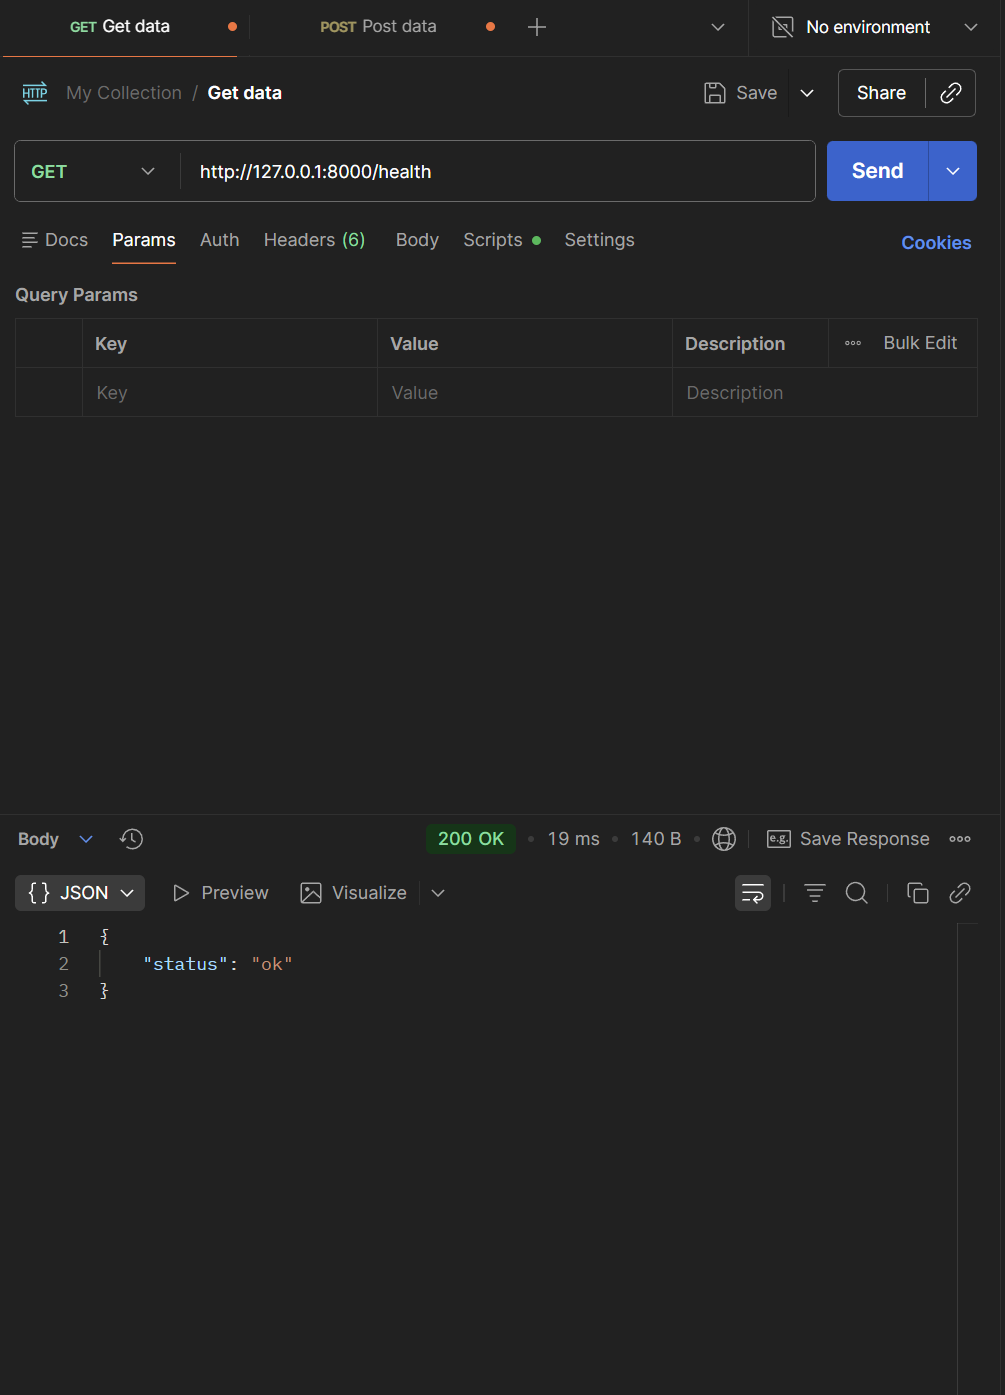  

Below is an image of the version endpoint:  
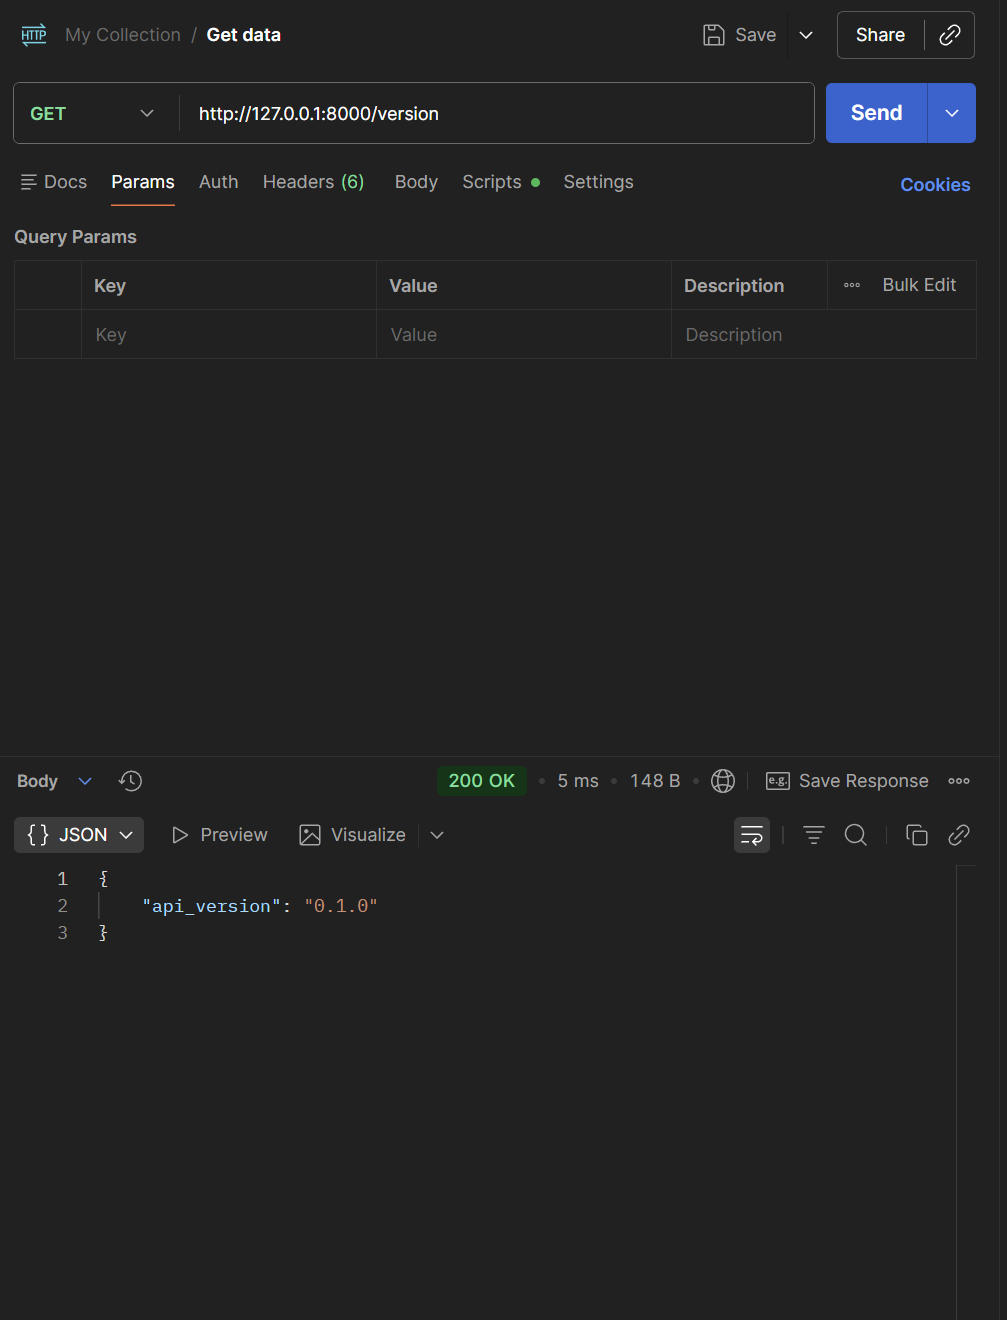  

Below is an image of the prediction endpoint (benign sample):  
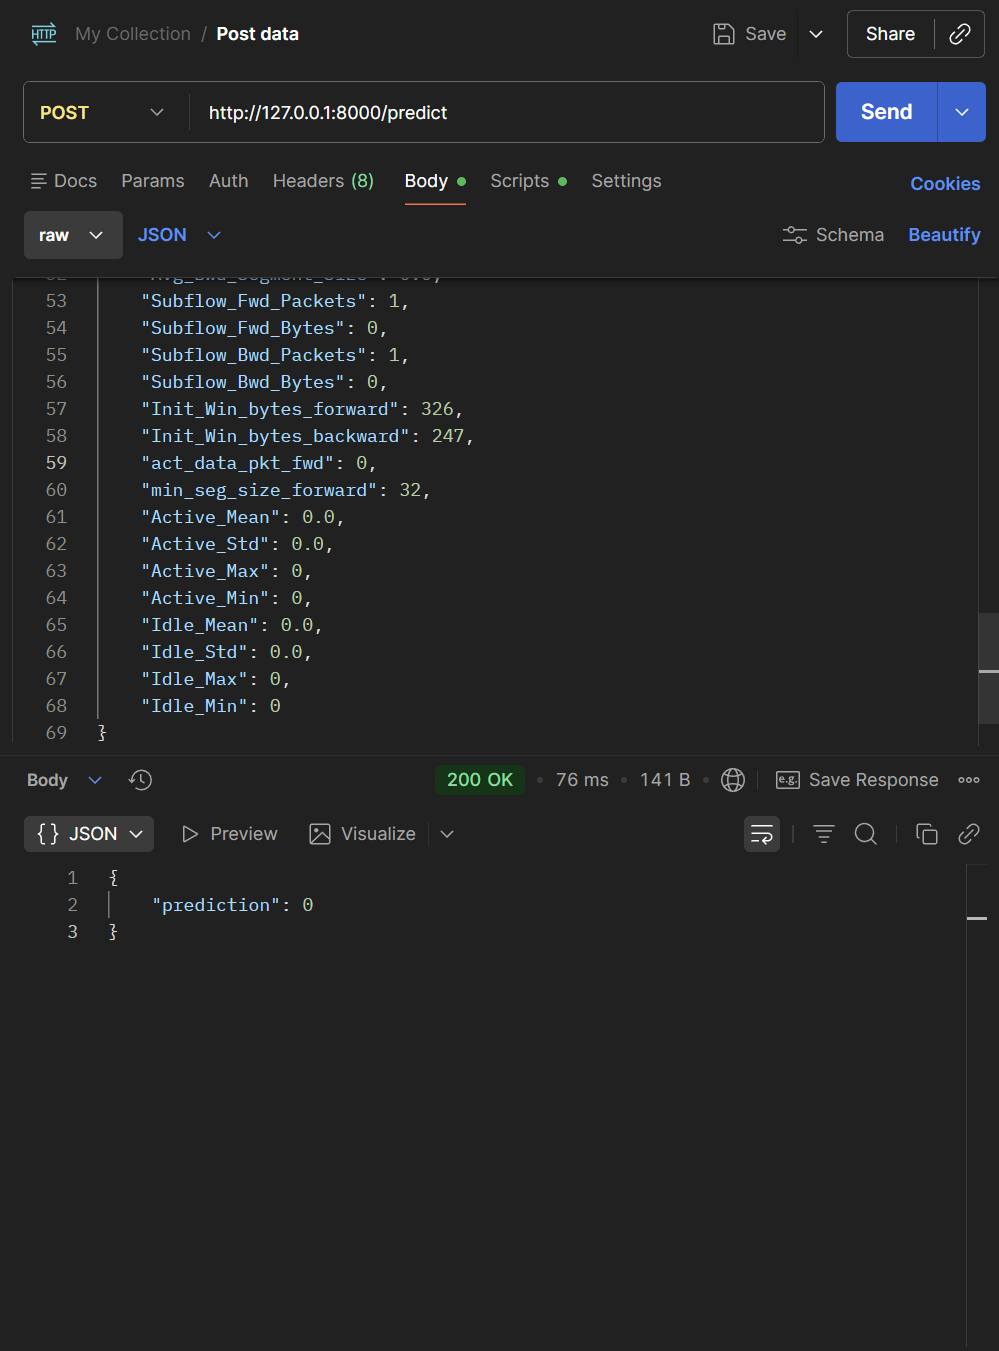  

Below is an image of the prediction endpoint (attack sample):  
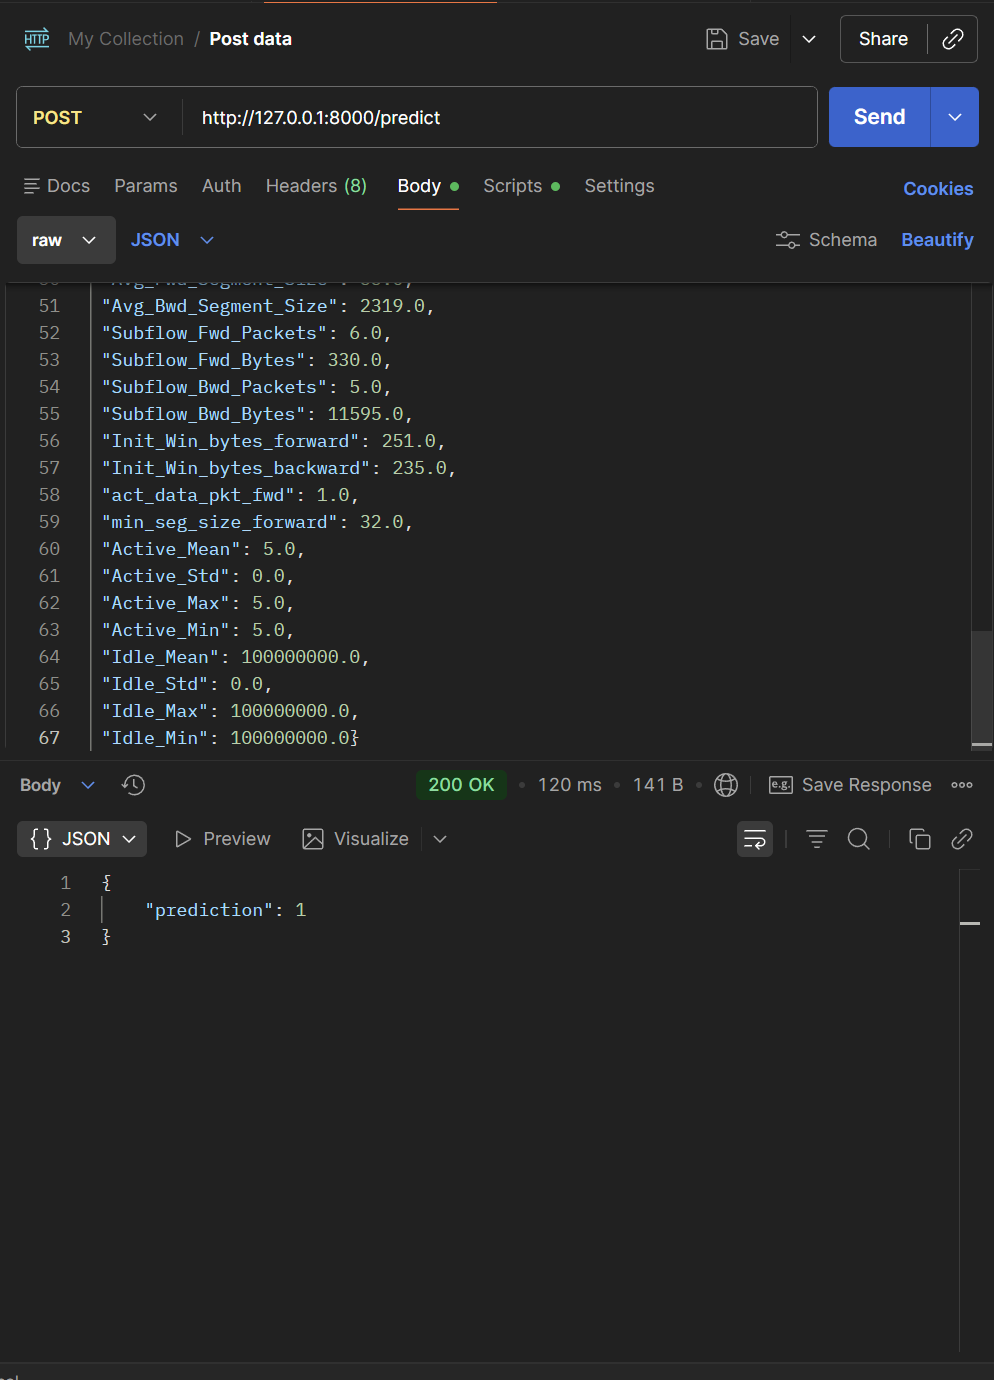  

**Notes for Team:**  
YAY!!! WE DID IT!!!



[12-09-2025] - [Emil] - [Deployment Unit Testing]

**What I worked on:**
- To completely test the API following its deployment, we need to design unit tests. 
- To do so, we will implement a test suite utilizing the samples we generated above. 
- Not going to go into depth about rationale - it is the same as above. 
- It would be of note that if this development were in a production setting, having separate modules for testing and deployment would be preferred. 

In [ ]:
import sys
from pathlib import Path
import json
import requests
import pandas as pd

# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from deployment.schema_loader import load_schema
from deployment.preprocessing import Preprocessor

# Load the schema
schema_path = project_root / "data" / "final_features.json"
schema = load_schema(schema_path)

# Create the preprocessor object
preprocessor = Preprocessor(schema_path)

# Setting dir variables, these files were generated earlier
sample_dir = project_root / "deployment" / "sample_requests"
benign_sample_path = sample_dir / "benign_sample.json"
attack_sample_path = sample_dir / "attack_sample.json"

# Manual preprocessor tests
X = preprocessor.preprocess_input(json.load(open(benign_sample_path)))
print("Shape: ", X.shape)
print(X[:2])

# API Tests (To Use, please ensure uvicorn is running)
API_URL_PREDICT = "http://127.0.0.1:8000/predict"
API_URL_HEALTH = "http://127.0.0.1:8000/health"
API_URL_VERSION = "http://127.0.0.1:8000/version"

def test_api(sample):
    response = requests.post(API_URL_PREDICT, json=sample)
    print(response.json())

print("Testing Benign Sample:")
test_api(json.load(open(benign_sample_path)))

print("Testing Attack Sample:")
test_api(json.load(open(attack_sample_path)))

Shape:  (1, 67)
[[-0.12268812 -0.97783797 -0.04946974 -0.02182382 -0.20158934 -0.02924796
  -0.70792984  0.18280939 -0.17773179 -0.85296348 -0.99067171  4.81304428
  -0.95889928 -1.00476992 -0.01461626 -0.23810427 -0.48429969 -0.75874324
  -0.89699739 -0.2445583  -0.93006766 -0.58817719 -0.75065174 -0.88987843
  -0.27254999 -0.47099066 -0.38903884 -0.40797675 -0.42789445 -0.07246097
  -0.14082754 -0.09095873 -0.04438    -0.26274349  0.33456355  1.24761349
  -1.00827487 -0.97762239 -1.03621571 -0.83563846 -0.3820254  -0.14082754
  -0.00640198 -0.75300439 -0.94962765 -0.15058181 -0.00640198  1.36670283
  -0.94863343 -0.17773179 -0.95889928 -0.04946974 -0.20158934 -0.02182382
  -0.02924677 -0.75958023 -0.14317981 -0.00879242 -1.75837367 -0.27039575
  -0.0770879  -0.27149488 -0.25964926 -0.85634609 -0.18780103 -0.87804704
  -0.83181229]]
Testing Benign Sample:
{'prediction': 0}
Testing Attack Sample:
{'prediction': 1}
